# 🏥 IUI Outcome Prediction: Model Training and Explainability

### 1. Setup and Utility Functions

In [30]:
from pathlib import Path
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"


def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir=None,
):
    if outdir is None:
        outdir = FIGURE_DIR / "confusion_matrices"
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg", "Preg"],
        yticklabels=["Non-Preg", "Preg"]
    )
    plt.title(f"{model_name} (threshold={threshold:.3f})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(outdir / f"{model_name}_cm.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir=None,
):
    if outdir is None:
        outdir = FIGURE_DIR / "roc_curves"
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)

    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.scatter(
        best_fpr,
        best_tpr,
        s=80,
        label=f"threshold={best_threshold:.2f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / f"{model_name}_roc.png")
    plt.close()


print("Setup complete")

Setup complete


### 2.Data Preprocessing and Train-Test Splitting

In [31]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer

PROJECT_ROOT = Path.cwd().parent  
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv"

df = pd.read_csv(DATA_PATH)
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_vals:
    raise ValueError(f"Unexpected values in Result: {bad_vals}")

df['Result'] = df['Result'].astype(int)

object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test  = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

cols_to_impute = [c for c in X_train.columns if c != 'HN']

all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols, errors='ignore')
    X_test  = X_test.drop(columns=all_nan_cols, errors='ignore')

cols_to_impute = [c for c in X_train.columns if c != 'HN']

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

X_train_num['HN'] = X_train['HN'].values
X_test_num['HN']  = X_test['HN'].values

train_hn = set(X_train_num['HN'])
test_hn  = set(X_test_num['HN'])
overlap  = train_hn.intersection(test_hn)

print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected"

X_train = X_train_num.drop(columns=['HN'])
X_test  = X_test_num.drop(columns=['HN'])

for col in ['Date', 'HN', 'Result']:
    assert col not in X_train.columns
    assert col not in X_test.columns

suspicious = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious:
    raise ValueError(f"Potential leakage columns: {suspicious}")

print(f'\nEvent rate full:  {y_full.mean():.4f}')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test:  {y_test.mean():.4f}')

print(f'\nSplit done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Number of features: {X_train.shape[1]}')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:",  int(y_test.sum()),  "out of", len(y_test))

Remaining object columns: ['HN']
HN overlap train/test: 0

Event rate full:  0.0621
Event rate train: 0.0605
Event rate test:  0.0687

Split done. Train: 2348, Test: 597
Number of features: 66
Train positives: 142 out of 2348
Test positives: 41 out of 597


### 3. Model Development, Imbalance Handling, and Evaluation

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import pandas as pd


MODEL_DIR = PROJECT_ROOT / "models" / "saved_models"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_list = []
trained_models = {}

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 8,
    'XGBoost': 20,
    'CatBoost': 30,
    'LightGBM': 20,
    'MLP': 4
}

samplers = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

model_names = ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'LightGBM', 'MLP']

for s_name, sampler in samplers.items():
    print(f"\n===== Imbalance Method: {s_name} =====")

    for m_name in model_names:
        print(f"  Training {m_name}...")

        sampler_copy = clone(sampler) if sampler is not None else None

        if m_name == 'LogisticRegression':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__max_depth': [5, 10, 20, None],
                'model__min_samples_leaf': [1, 2, 5]
            }

        elif m_name == 'XGBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4, 5],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]
            }

        elif m_name == 'CatBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300, 500],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5, 10]
            }

        elif m_name == 'LightGBM':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight='balanced',
                        verbose=-1
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight=None,
                        verbose=-1
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [3, 4, 5, 6, -1],
                'model__num_leaves': [15, 31, 63],
                'model__min_child_samples': [10, 20, 50]
            }

        elif m_name == 'MLP':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50), (100, 100)],
                'model__alpha': [0.0001, 0.001, 0.01]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=n_iter_map[m_name],
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        print(f"    Best params: {rs.best_params_}")

        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        brier   = brier_score_loss(y_test, y_prob)

        y_pred = (y_prob >= th).astype(int)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)

        print(
            f"    PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, F1={f1:.4f}, Th={th:.4f}"
        )

        results_list.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Threshold': th
        })

        key = f"{m_name}__{s_name}"
        trained_models[key] = {
            'model': best_m,
            'probabilities': y_prob,
            'threshold': th,
            'best_params': rs.best_params_,
            'train_oof_probs': oof_prob
        }

        model_path = MODEL_DIR / m_name
        model_path.mkdir(parents=True, exist_ok=True)
        joblib.dump(best_m, model_path / f'{m_name}_{s_name}.joblib')


results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    REPORT_DIR / 'model_performance_comparison.xlsx',
    index=False
)

print('\nModel training complete.')
print(results_df.head(15))


===== Imbalance Method: Baseline_NoResampling =====
  Training LogisticRegression...
    Best params: {'model__C': 0.01}
    PR-AUC=0.1029, ROC-AUC=0.6779, Brier=0.2128, F1=0.1789, Th=0.4085
  Training RandomForest...
    Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_depth': 20}
    PR-AUC=0.1035, ROC-AUC=0.6574, Brier=0.0701, F1=0.1830, Th=0.1339
  Training XGBoost...
    Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.005, 'model__colsample_bytree': 0.8}
    PR-AUC=0.1335, ROC-AUC=0.6989, Brier=0.2141, F1=0.2000, Th=0.5229
  Training CatBoost...
    Best params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 100, 'model__depth': 3}
    PR-AUC=0.1132, ROC-AUC=0.6935, Brier=0.2239, F1=0.1775, Th=0.4692
  Training LightGBM...
    Best params: {'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 3, 'm

In [33]:
import pandas as pd


if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model training block first.")

all_methods_df = results_df.copy()

desired_cols = [
    'Imbalance_Method',
    'Model',
    'Best_Params',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC',
    'Brier',
    'Optimal_Threshold',
]

for c in desired_cols:
    if c not in all_methods_df.columns:
        all_methods_df[c] = pd.NA

all_methods_df = all_methods_df[desired_cols].copy()

# Drop duplicates
before_drop = len(all_methods_df)
all_methods_df = all_methods_df.drop_duplicates(
    subset=['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()
after_drop = len(all_methods_df)

if before_drop != after_drop:
    print(f"  Dropped {before_drop - after_drop} duplicate rows")

print(f"Total combinations: {len(all_methods_df)}")

# Sort
all_methods_df = all_methods_df.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# Rank columns
all_methods_df['Rank_PR_AUC'] = all_methods_df['PR-AUC'].rank(ascending=False, method='min')
all_methods_df['Rank_ROC_AUC'] = all_methods_df['ROC-AUC'].rank(ascending=False, method='min')
all_methods_df['Rank_Brier'] = all_methods_df['Brier'].rank(ascending=True, method='min')

# Rounded display version
all_methods_display = all_methods_df.copy()

metric_cols = [
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold'
]

for c in metric_cols:
    all_methods_display[c] = pd.to_numeric(all_methods_display[c], errors='coerce').round(4)

all_methods_display['Rank_PR_AUC'] = all_methods_display['Rank_PR_AUC'].astype('Int64')
all_methods_display['Rank_ROC_AUC'] = all_methods_display['Rank_ROC_AUC'].astype('Int64')
all_methods_display['Rank_Brier'] = all_methods_display['Rank_Brier'].astype('Int64')

# Save
all_methods_display.to_excel(REPORT_DIR / 'all_methods_metric_summary.xlsx', index=False)
all_methods_display.to_csv(REPORT_DIR / 'all_methods_metric_summary.csv', index=False)

print("\nTop 15 methods by PR-AUC")
print(all_methods_display[
    ['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier', 'F1', 'Rank_PR_AUC']
].head(15).to_string())



# Top-5 Methods Table (manuscript-ready)

paper_top5 = all_methods_df.copy()

paper_top5 = paper_top5.drop_duplicates(
    subset=['Imbalance_Method', 'Model', 'PR-AUC', 'ROC-AUC', 'Brier']
).sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).head(5).reset_index(drop=True).copy()

paper_top5.insert(0, 'Rank', range(1, len(paper_top5) + 1))

paper_top5 = paper_top5[[
    'Rank', 'Model', 'Imbalance_Method',
    'PR-AUC', 'ROC-AUC', 'Brier', 'Best_Params'
]].copy()

paper_top5_display = paper_top5.copy()
for c in ['PR-AUC', 'ROC-AUC', 'Brier']:
    paper_top5_display[c] = pd.to_numeric(paper_top5_display[c], errors='coerce').round(4)

paper_top5_display.to_excel(REPORT_DIR / 'top5_methods_for_manuscript.xlsx', index=False)
paper_top5_display.to_csv(REPORT_DIR / 'top5_methods_for_manuscript.csv', index=False)

print("\nTop 5 methods:")
print(paper_top5_display)


# Pretty Labels for Manuscript Table

pretty_top5 = paper_top5_display.copy()

pretty_map = {
    'Baseline_NoResampling': 'No resampling',
    'SMOTE': 'SMOTE',
    'ADASYN': 'ADASYN',
    'BorderlineSMOTE': 'Borderline-SMOTE',
    'SMOTETomek': 'SMOTE-Tomek'
}

pretty_top5['Imbalance_Method'] = pretty_top5['Imbalance_Method'].replace(pretty_map)

pretty_top5 = pretty_top5.rename(columns={
    'Imbalance_Method': 'Imbalance handling',
    'Brier': 'Brier score',
    'Best_Params': 'Best hyperparameters'
})

pretty_top5.to_excel(REPORT_DIR / 'top5_methods_for_manuscript_pretty.xlsx', index=False)
pretty_top5.to_csv(REPORT_DIR / 'top5_methods_for_manuscript_pretty.csv', index=False)

print("\nManuscript-ready top-5 table:")
print(pretty_top5)

Total combinations: 30

Top 15 methods by PR-AUC
                 Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier      F1  Rank_PR_AUC
0              XGBoost  Baseline_NoResampling  0.1335   0.6989  0.2141  0.2000            1
1             CatBoost             SMOTETomek  0.1323   0.7151  0.1402  0.1767            2
2             CatBoost                  SMOTE  0.1265   0.7182  0.1407  0.1714            3
3             LightGBM  Baseline_NoResampling  0.1161   0.6914  0.2016  0.1860            4
4              XGBoost             SMOTETomek  0.1153   0.6853  0.0797  0.1944            5
5   LogisticRegression        BorderlineSMOTE  0.1147   0.6819  0.1791  0.1778            6
6             LightGBM             SMOTETomek  0.1134   0.6967  0.0680  0.2024            7
7         RandomForest                  SMOTE  0.1134   0.6478  0.0696  0.1826            8
8             CatBoost  Baseline_NoResampling  0.1132   0.6935  0.2239  0.1775            9
9             LightGBM        B

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ==========================================
# Confusion Matrix for Best Model
# Final model: CatBoost + SMOTE
# ==========================================

model_name  = "CatBoost"
method_name = "SMOTE"
model_key   = f"{model_name}__{method_name}"

threshold = trained_models[model_key]["threshold"]

y_prob = trained_models[model_key]["probabilities"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv         = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Final model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold,
    outdir=FIGURE_DIR / "confusion_matrices"
)

Final model: CatBoost__SMOTE
Threshold: 0.3233
Confusion matrix:
[[181 375]
 [  2  39]]
TN=181, FP=375, FN=2, TP=39
Sensitivity: 0.951
Specificity: 0.326
Precision (PPV): 0.094
NPV: 0.989


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ==========================================
# Confusion Matrix for Best Model
# Final model: XGBoost + Baseline_NoResampling
# ==========================================

model_name  = "XGBoost"
method_name = "Baseline_NoResampling"
model_key   = f"{model_name}__{method_name}"

threshold = trained_models[model_key]["threshold"]

y_prob = trained_models[model_key]["probabilities"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv         = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Final model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold,
    outdir=FIGURE_DIR / "confusion_matrices"
)

Final model: XGBoost__Baseline_NoResampling
Threshold: 0.5229
Confusion matrix:
[[363 193]
 [ 15  26]]
TN=363, FP=193, FN=15, TP=26
Sensitivity: 0.634
Specificity: 0.653
Precision (PPV): 0.119
NPV: 0.960


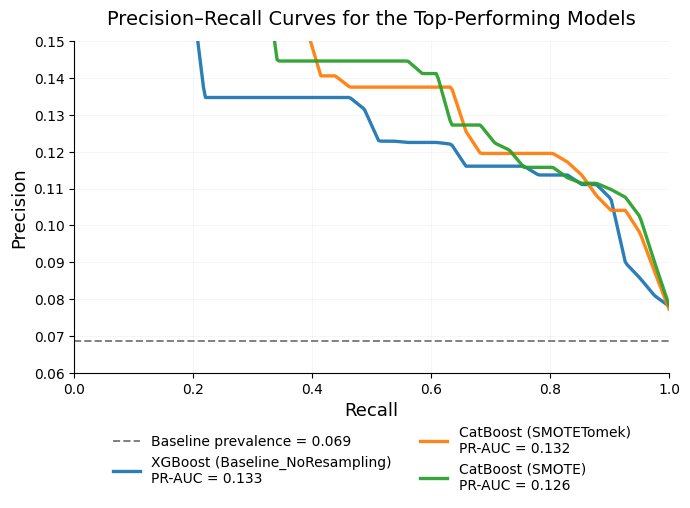

In [36]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Precision–Recall Curves for Top-Performing Models
# ==========================================

top_n = 3

top_models_df = results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).head(top_n)

pr_curve_dir = FIGURE_DIR / "pr_curves"
pr_curve_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
ax.set_facecolor("white")

baseline_prevalence = y_test.mean()

ax.axhline(
    baseline_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.4,
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

recall_grid = np.linspace(0, 1, 300)

for _, row in top_models_df.iterrows():

    model_name  = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc      = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob    = trained_models[model_key]["probabilities"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    order     = np.argsort(recall)
    recall    = recall[order]
    precision = precision[order]

    uniq_recall    = np.unique(recall)
    uniq_precision = np.array([
        precision[recall == r].max() for r in uniq_recall
    ])

    precision_env    = np.maximum.accumulate(uniq_precision[::-1])[::-1]
    precision_smooth = np.interp(recall_grid, uniq_recall, precision_env)

    label = f"{model_name} ({method_name})\nPR-AUC = {pr_auc:.3f}"

    ax.plot(
        recall_grid,
        precision_smooth,
        linewidth=2.4,
        alpha=0.95,
        label=label
    )

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curves for the Top-Performing Models", fontsize=14, pad=12)

ax.set_xlim(0, 1)
ax.set_ylim(0.06, 0.15)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.15, linewidth=0.6)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.97])

plt.savefig(
    pr_curve_dir / "top_models_pr_curve_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

Top 20 features by importance:
hCG_Type                           29.219909
Total_Female_Pathology             18.883949
Thin_Endometrium                    9.880906
Advanced_Age                        6.990787
Uterine_Factors                     6.436601
Cumulative_Treatment                4.636752
Endo_Type_Triple                    3.812092
Cycle_Number                        3.707913
Cycle_Day                           3.062301
Endo_Type_Intermediate              2.680589
Number_Of_Miscarriages              2.581928
Mature_Follicle_Count               2.435567
Infertility_Type                    1.279638
Menstrual                           1.023236
Pregnancy_History                   0.821109
BMI_InfertilityType_Interaction     0.729237
OI_Clomiphene                       0.655509
Ovulatory_Factors                   0.433333
Menstrual_Duration_Days             0.096456
Age_Female                          0.094746
dtype: float64
  k=  1: PR-AUC = 0.0647 ± 0.0079
  k= 10: PR-AUC = 0.

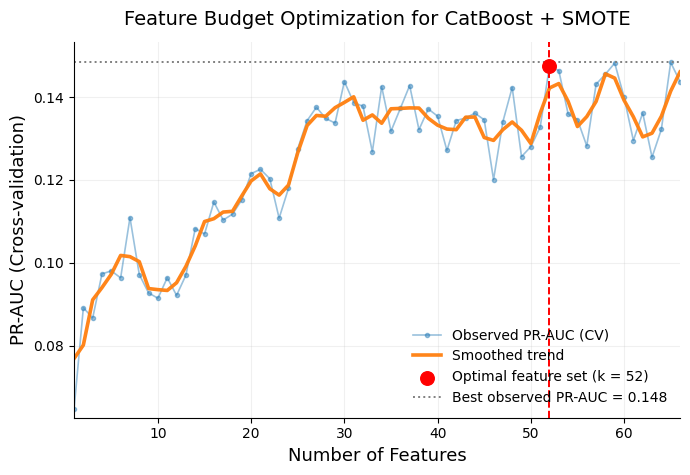

In [37]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Feature Budget Optimization (CatBoost + SMOTE)
# ==========================================

final_model_key = "CatBoost__SMOTE"
cat_model = trained_models[final_model_key]["model"]

booster = cat_model.named_steps["model"] if hasattr(cat_model, "named_steps") else cat_model

feat_importance = pd.Series(
    booster.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 features by importance:")
print(feat_importance.head(20))

# -----------------------------
# Feature budget loop
# -----------------------------
group_cv_budget = GroupKFold(n_splits=3)
budget_results  = []

for k in range(1, len(feat_importance) + 1):

    top_k_features = feat_importance.index[:k].tolist()
    X_train_k      = X_train[top_k_features]
    model_k        = clone(booster)

    scores = cross_val_score(
        model_k,
        X_train_k,
        y_train,
        groups=groups_train,
        cv=group_cv_budget,
        scoring="average_precision",
        n_jobs=-1
    )

    budget_results.append({
        "Num_Features": k,
        "PR-AUC":       scores.mean(),
        "PR-AUC_std":   scores.std()
    })

    if k % 10 == 0 or k == 1:
        print(f"  k={k:3d}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

budget_df_cat = pd.DataFrame(budget_results)

# -----------------------------
# หา optimal k
# -----------------------------
max_score_cat = budget_df_cat["PR-AUC"].max()
max_idx       = budget_df_cat["PR-AUC"].idxmax()
se_at_max     = budget_df_cat.loc[max_idx, "PR-AUC_std"] / np.sqrt(3)
threshold_1se = max_score_cat - se_at_max

optimal_k_cat = budget_df_cat.loc[
    budget_df_cat["PR-AUC"] >= threshold_1se,
    "Num_Features"
].min()

print(f"\nMax PR-AUC: {max_score_cat:.4f} at k={budget_df_cat.loc[max_idx, 'Num_Features']}")
print(f"1-SE threshold: {threshold_1se:.4f}")
print(f"Optimal k (1-SE rule): {optimal_k_cat}")

# Save budget table
budget_df_cat.to_excel(REPORT_DIR / "feature_budget_catboost.xlsx", index=False)
print("\nFeature budget optimization complete")
print(budget_df_cat.head(10))


# ==========================================
# Feature Budget Plot (CatBoost + SMOTE)
# ==========================================

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor("white")

x = budget_df_cat["Num_Features"]
y = budget_df_cat["PR-AUC"]

y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

ax.plot(
    x, y,
    marker="o",
    markersize=3,
    lw=1.2,
    alpha=0.45,
    label="Observed PR-AUC (CV)"
)

ax.plot(
    x, y_smooth,
    lw=2.6,
    alpha=0.95,
    label="Smoothed trend"
)

opt_y = budget_df_cat.loc[
    budget_df_cat["Num_Features"] == optimal_k_cat,
    "PR-AUC"
].iloc[0]

ax.scatter(
    optimal_k_cat, opt_y,
    s=95,
    color="red",
    zorder=6,
    label=f"Optimal feature set (k = {optimal_k_cat})"
)

ax.axhline(
    y=max_score_cat,
    linestyle=":",
    linewidth=1.4,
    color="gray",
    label=f"Best observed PR-AUC = {max_score_cat:.3f}"
)

ax.axvline(
    x=optimal_k_cat,
    linestyle="--",
    linewidth=1.4,
    color="red"
)

ax.set_xlabel("Number of Features", fontsize=13)
ax.set_ylabel("PR-AUC (Cross-validation)", fontsize=13)
ax.set_title("Feature Budget Optimization for CatBoost + SMOTE", fontsize=14, pad=12)

ax.set_xlim(1, x.max())
ax.set_ylim(y.min() - 0.002, y.max() + 0.005)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)

ax.legend(loc="lower right", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    FIGURE_DIR / "feature_budget_catboost_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Top 20 features by importance:
Uterine_Factors                    0.075656
Total_Female_Pathology             0.055389
Ovulatory_Factors                  0.045862
Cycle_Day                          0.039680
First_Count                        0.037691
Pre_Count                          0.036933
Post_TPMSC                         0.034115
Gynecological_Surgical_History     0.031796
Delta_Motile                       0.029400
Age_Female                         0.028938
First_Volume                       0.027768
Post_Count                         0.027762
Menstrual_Interval_Days            0.025447
First_Progressive_Motile           0.025427
First_TPMSC                        0.024925
BMI_InfertilityType_Interaction    0.024556
Ratio_TPMSC                        0.024235
Pre_Motile                         0.023030
Age_FSH_Interaction                0.022783
First_Motile                       0.021417
dtype: float32
  k=  1: PR-AUC = 0.0786 ± 0.0053
  k= 10: PR-AUC = 0.1236 ± 0.0239
  k= 2

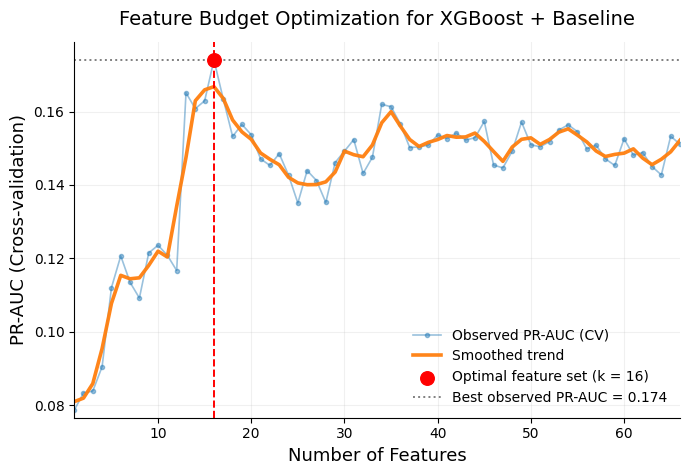

In [38]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Feature Budget Optimization (XGBoost + Baseline_NoResampling)

final_model_key = "XGBoost__Baseline_NoResampling"
xgb_model = trained_models[final_model_key]["model"]

booster = xgb_model.named_steps["model"] if hasattr(xgb_model, "named_steps") else xgb_model

feat_importance = pd.Series(
    booster.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 features by importance:")
print(feat_importance.head(20))


# Feature budget loop
group_cv_budget = GroupKFold(n_splits=3)
budget_results  = []

for k in range(1, len(feat_importance) + 1):

    top_k_features = feat_importance.index[:k].tolist()
    X_train_k      = X_train[top_k_features]
    model_k        = clone(booster)

    scores = cross_val_score(
        model_k,
        X_train_k,
        y_train,
        groups=groups_train,
        cv=group_cv_budget,
        scoring="average_precision",
        n_jobs=-1
    )

    budget_results.append({
        "Num_Features": k,
        "PR-AUC":       scores.mean(),
        "PR-AUC_std":   scores.std()
    })

    if k % 10 == 0 or k == 1:
        print(f"  k={k:3d}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

budget_df_xgb = pd.DataFrame(budget_results)

max_score_xgb = budget_df_xgb["PR-AUC"].max()
max_idx       = budget_df_xgb["PR-AUC"].idxmax()
se_at_max     = budget_df_xgb.loc[max_idx, "PR-AUC_std"] / np.sqrt(3)
threshold_1se = max_score_xgb - se_at_max

optimal_k_xgb = budget_df_xgb.loc[
    budget_df_xgb["PR-AUC"] >= threshold_1se,
    "Num_Features"
].min()

print(f"\nMax PR-AUC: {max_score_xgb:.4f} at k={budget_df_xgb.loc[max_idx, 'Num_Features']}")
print(f"1-SE threshold: {threshold_1se:.4f}")
print(f"Optimal k (1-SE rule): {optimal_k_xgb}")

# Save budget table
budget_df_xgb.to_excel(REPORT_DIR / "feature_budget_xgb.xlsx", index=False)
print("\nFeature budget optimization complete")
print(budget_df_xgb.head(10))



# Feature Budget Plot (XGBoost + Baseline_NoResampling)

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor("white")

x = budget_df_xgb["Num_Features"]
y = budget_df_xgb["PR-AUC"]

y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

ax.plot(
    x, y,
    marker="o",
    markersize=3,
    lw=1.2,
    alpha=0.45,
    label="Observed PR-AUC (CV)"
)

ax.plot(
    x, y_smooth,
    lw=2.6,
    alpha=0.95,
    label="Smoothed trend"
)

opt_y = budget_df_xgb.loc[
    budget_df_xgb["Num_Features"] == optimal_k_xgb,
    "PR-AUC"
].iloc[0]

ax.scatter(
    optimal_k_xgb, opt_y,
    s=95,
    color="red",
    zorder=6,
    label=f"Optimal feature set (k = {optimal_k_xgb})"
)

ax.axhline(
    y=max_score_xgb,
    linestyle=":",
    linewidth=1.4,
    color="gray",
    label=f"Best observed PR-AUC = {max_score_xgb:.3f}"
)

ax.axvline(
    x=optimal_k_xgb,
    linestyle="--",
    linewidth=1.4,
    color="red"
)

ax.set_xlabel("Number of Features", fontsize=13)
ax.set_ylabel("PR-AUC (Cross-validation)", fontsize=13)
ax.set_title("Feature Budget Optimization for XGBoost + Baseline", fontsize=14, pad=12)

ax.set_xlim(1, x.max())
ax.set_ylim(y.min() - 0.002, y.max() + 0.005)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)

ax.legend(loc="lower right", frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    FIGURE_DIR / "feature_budget_xgb_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [39]:
from xgboost import XGBClassifier
import joblib

# Retrain XGBoost with Optimal k Features
# Final model: XGBoost + Baseline_NoResampling

selected_features_xgb = feat_importance.index[:optimal_k_xgb].tolist()

print(f"Selected {optimal_k_xgb} features:")
for i, f in enumerate(selected_features_xgb, start=1):
    print(f"  {i}. {f}")

X_train_final = X_train[selected_features_xgb].copy()
X_test_final  = X_test[selected_features_xgb].copy()


best_params = trained_models["XGBoost__Baseline_NoResampling"]["best_params"]

clean_params = {
    k.replace("model__", ""): v
    for k, v in best_params.items()
}

final_xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    **clean_params
)

final_xgb_model.fit(X_train_final, y_train)

print(f"\nRetrained XGBoost with {optimal_k_xgb} features")
print(f"Best params used: {clean_params}")


# Save final model
final_model_dir = MODEL_DIR / "final_model"
final_model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_xgb_model,
    final_model_dir / "XGBoost_Baseline_final_feature_budget_model.joblib"
)

joblib.dump(
    selected_features_xgb,
    final_model_dir / "XGBoost_Baseline_selected_features.joblib"
)

print(f"\nSaved final model to: {final_model_dir}")

Selected 16 features:
  1. Uterine_Factors
  2. Total_Female_Pathology
  3. Ovulatory_Factors
  4. Cycle_Day
  5. First_Count
  6. Pre_Count
  7. Post_TPMSC
  8. Gynecological_Surgical_History
  9. Delta_Motile
  10. Age_Female
  11. First_Volume
  12. Post_Count
  13. Menstrual_Interval_Days
  14. First_Progressive_Motile
  15. First_TPMSC
  16. BMI_InfertilityType_Interaction

Retrained XGBoost with 16 features
Best params used: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.005, 'colsample_bytree': 0.8}

Saved final model to: e:\Ph D\Research\iui_ml_prediction\models\saved_models\final_model


Final features used:
  1. Uterine_Factors
  2. Total_Female_Pathology
  3. Ovulatory_Factors
  4. Cycle_Day
  5. First_Count
  6. Pre_Count
  7. Post_TPMSC
  8. Gynecological_Surgical_History
  9. Delta_Motile
  10. Age_Female
  11. First_Volume
  12. Post_Count
  13. Menstrual_Interval_Days
  14. First_Progressive_Motile
  15. First_TPMSC
  16. BMI_InfertilityType_Interaction

Final model performance on test set:
PR-AUC:  0.1284
ROC-AUC: 0.6736
Brier:   0.2200

Top SHAP features:
                            Feature               Feature_Display  Importance
0                   Uterine_Factors                Uterine Factor    0.251002
1            Total_Female_Pathology        Total Female Pathology    0.081665
2           Menstrual_Interval_Days         Cycle Interval (days)    0.049381
3                        Post_TPMSC                Postwash TPMSC    0.048078
4                         Pre_Count           Prewash Sperm Count    0.035840
5                      Delta_Motile          D

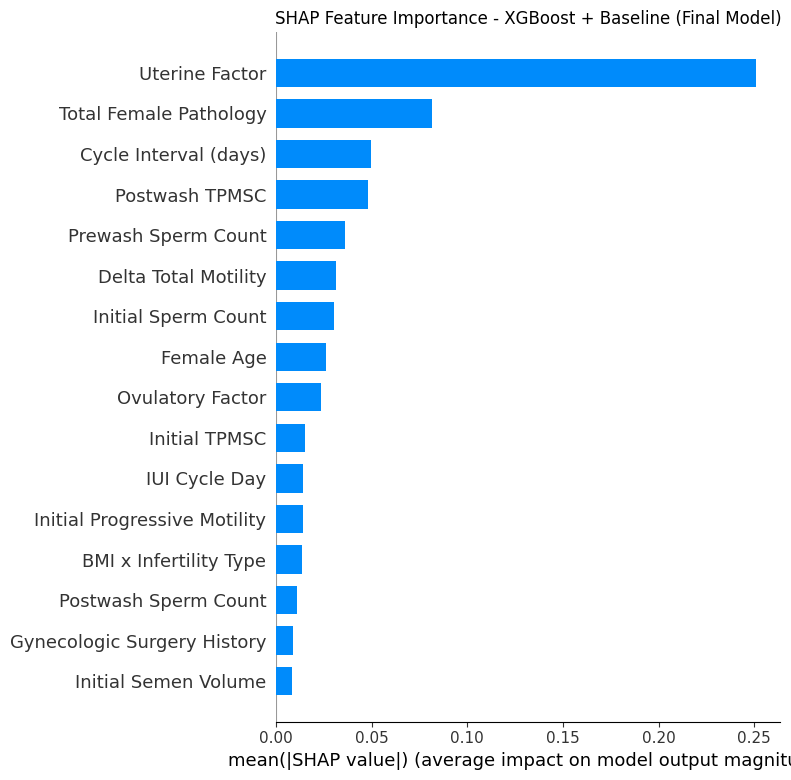

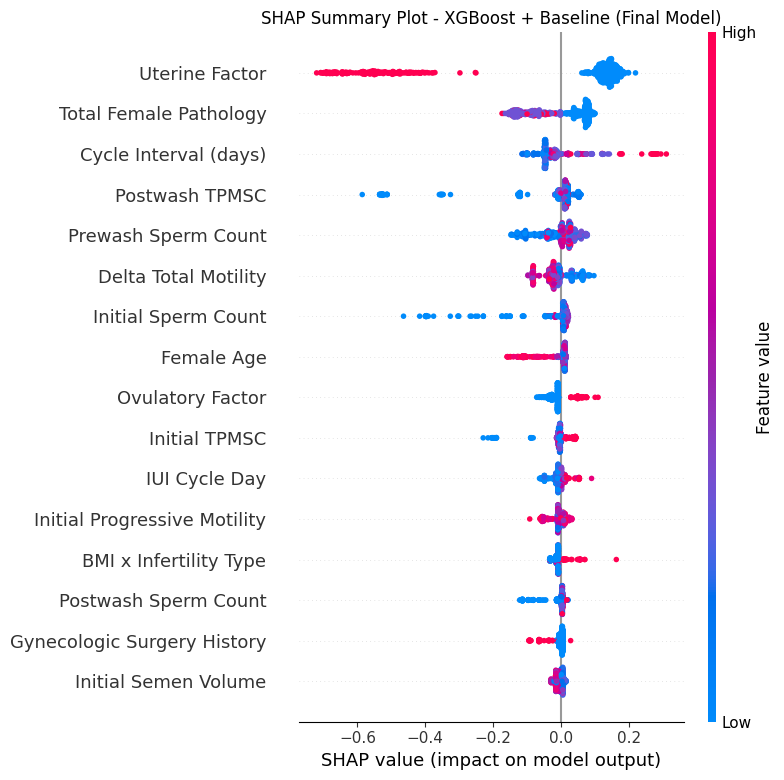


Block 7 complete.


In [40]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)


# Final model: XGBoost + Baseline_NoResampling (Feature-Budget)

required_objects = [
    "selected_features_xgb",
    "final_xgb_model",
    "X_test",
    "y_test",
    "test_info"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

final_features = selected_features_xgb.copy()

missing_features = [f for f in final_features if f not in X_test.columns]
if missing_features:
    raise ValueError(f"These final features are missing from X_test: {missing_features}")

X_test_final = X_test[final_features].copy()

print("Final features used:")
for i, f in enumerate(final_features, start=1):
    print(f"  {i}. {f}")


# Performance on test set
final_probs   = final_xgb_model.predict_proba(X_test_final)[:, 1]
final_pr_auc  = average_precision_score(y_test, final_probs)
final_roc_auc = roc_auc_score(y_test, final_probs)
final_brier   = brier_score_loss(y_test, final_probs)

print("\nFinal model performance on test set:")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Brier:   {final_brier:.4f}")


# Save performance summary
final_model_summary = pd.DataFrame([{
    "Model": "XGBoost + Baseline (Final Feature-Budget Model)",
    "Num_Features": len(final_features),
    "PR-AUC":  final_pr_auc,
    "ROC-AUC": final_roc_auc,
    "Brier":   final_brier
}])

final_model_summary.to_excel(
    REPORT_DIR / "Final_Model_Performance_XGBoost_Baseline.xlsx",
    index=False
)


# Save selected features
final_features_df = pd.DataFrame({
    "Rank":    range(1, len(final_features) + 1),
    "Feature": final_features
})

final_features_df.to_excel(
    REPORT_DIR / "Final_Selected_Features_XGBoost_Baseline.xlsx",
    index=False
)


# Save test predictions
final_test_pred_df = test_info.copy()
final_test_pred_df["y_true"] = y_test.values
final_test_pred_df["y_prob"] = final_probs

final_test_pred_df.to_excel(
    REPORT_DIR / "Final_Test_Predictions_XGBoost_Baseline.xlsx",
    index=False
)


# Feature display name mapping
feature_name_map = {
    'Age_Female': 'Female Age',
    'Body_Mass_Index': 'BMI',
    'Total_infertile_duration': 'Infertility Duration',
    'Infertility_Type': 'Primary Infertility',
    'Pregnancy_History': 'Previous Pregnancy',
    'Number_Of_Alive_Children': 'Number of Children',
    'Number_Of_Miscarriages': 'Number of Miscarriages',
    'Menstrual': 'Regular Menstrual Cycle',
    'Menstrual_Interval_Days': 'Cycle Interval (days)',
    'Menstrual_Duration_Days': 'Menstrual Duration (days)',
    'Dysmenorrhea': 'Dysmenorrhea',
    'FSH_Baseline': 'Baseline FSH',
    'LH_Baseline': 'Baseline LH',
    'E2_Baseline': 'Baseline Estradiol',
    'PRL_Baseline': 'Baseline Prolactin',
    'Uterine_Factors': 'Uterine Factor',
    'Tubal_Factors': 'Tubal Factor',
    'Ovarian_Factors': 'Ovarian Factor',
    'Ovulatory_Factors': 'Ovulatory Factor',
    'Cervical_Factors': 'Cervical Factor',
    'Endometriosis_Factors': 'Endometriosis',
    'Multisystem_Factors': 'Multiple Infertility Factors',
    'Gynecological_Surgical_History': 'Gynecologic Surgery History',
    'Alcohol': 'Male Alcohol Consumption',
    'Smoke': 'Male Smoking',
    'First_Volume': 'Initial Semen Volume',
    'First_Count': 'Initial Sperm Count',
    'First_Motile': 'Initial Motility',
    'First_Progressive_Motile': 'Initial Progressive Motility',
    'First_Normal_Morpho': 'Initial Normal Morphology',
    'Pre_Volume': 'Prewash Volume',
    'Pre_Count': 'Prewash Sperm Count',
    'Pre_Motile': 'Prewash Motility',
    'Pre_Progressive_Motile': 'Prewash Progressive Motility',
    'Pre_TPMSC': 'Prewash TPMSC',
    'Post_Count': 'Postwash Sperm Count',
    'Post_Motile': 'Postwash Motility',
    'Post_Progressive_Motile': 'Postwash Progressive Motility',
    'Post_TPMSC': 'Postwash TPMSC',
    'Cycle_Type': 'Cycle Type',
    'Cycle_Day': 'IUI Cycle Day',
    'Cycle_Number': 'IUI Cycle Number',
    'Ovary_Stimulation_Round': 'Stimulation Round',
    'OI_Clomiphene': 'Clomiphene',
    'OI_Letrozole': 'Letrozole',
    'OI_Gonadotropins': 'Gonadotropins',
    'hCG_Used': 'hCG Trigger Used',
    'hCG_Type': 'hCG Type',
    'Mature_Follicle_Count': 'Mature Follicle Count',
    'Endometrium_Thickness': 'Endometrial Thickness',
    'Endo_Type_Triple': 'Triple Line Endometrium',
    'Endo_Type_Intermediate': 'Intermediate Endometrium',
    'Endo_Type_Mixed': 'Mixed Endometrium',
    'Ratio_TPMSC': 'TPMSC Wash Ratio',
    'Delta_Progressive_Motile': 'Delta Progressive Motility',
    'Delta_Motile': 'Delta Total Motility',
    'Follicle_Endo_Product': 'Follicle x Endometrium',
    'Cumulative_Treatment': 'Cumulative Treatment',
    'Age_FSH_Interaction': 'Age x FSH',
    'BMI_InfertilityType_Interaction': 'BMI x Infertility Type',
    'Total_Female_Pathology': 'Total Female Pathology',
    'First_TPMSC': 'Initial TPMSC',
    'Low_TPMSC': 'Low Postwash TPMSC',
    'Thin_Endometrium': 'Thin Endometrium',
    'Advanced_Age': 'Advanced Maternal Age',
}

display_names              = [feature_name_map.get(f, f) for f in final_features]
X_test_final_named         = X_test_final.copy()
X_test_final_named.columns = display_names


# SHAP analysis
explainer   = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_test_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if not isinstance(shap_values, np.ndarray):
    raise ValueError("Unexpected SHAP output format.")

if shap_values.shape[1] != X_test_final.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_test_final has {X_test_final.shape[1]} features."
    )

feat_imp_final_xgb = pd.DataFrame({
    "Feature":         final_features,
    "Feature_Display": display_names,
    "Importance":      np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_final_xgb.to_excel(
    REPORT_DIR / "SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx",
    index=False
)

print("\nTop SHAP features:")
print(feat_imp_final_xgb.to_string())


# SHAP bar plot
shap_dir = FIGURE_DIR / "shap_final_xgb"
shap_dir.mkdir(parents=True, exist_ok=True)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    plot_type="bar",
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Feature Importance - XGBoost + Baseline (Final Model)")
plt.tight_layout()
plt.savefig(
    shap_dir / "SHAP_Bar_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# SHAP beeswarm plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Summary Plot - XGBoost + Baseline (Final Model)")
plt.tight_layout()
plt.savefig(
    shap_dir / "SHAP_Beeswarm_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("\nBlock 7 complete.")

HN overlap between subtrain and calibration set: 0
Subtrain size: 1867
Calibration size: 481
Subtrain positives: 112 / 1867
Calibration positives: 30 / 481

Brier before calibration: 0.2193
Brier after calibration:  0.0642
Improvement:              0.1551

Raw probability summary:
count    597.000000
mean       0.455965
std        0.115965
min        0.181643
25%        0.363582
50%        0.490362
75%        0.551824
max        0.630773
dtype: float64

Calibrated probability summary:
count    597.000000
mean       0.062261
std        0.053645
min        0.000000
25%        0.026846
50%        0.038760
75%        0.099379
max        0.648654
dtype: float64


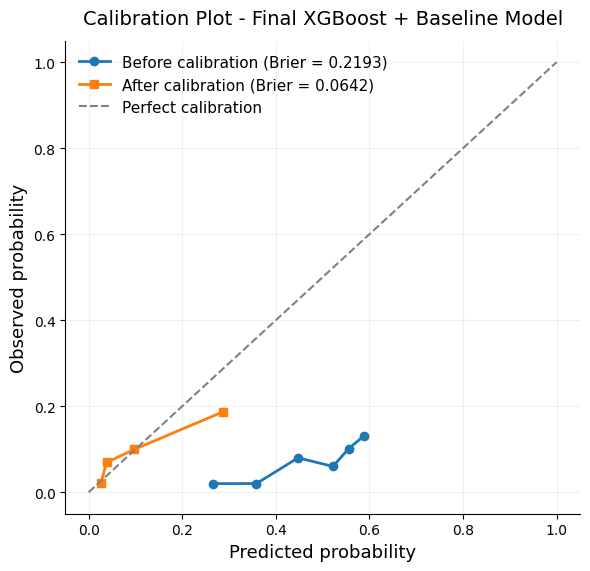


Group-aware calibration complete.


In [41]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GroupShuffleSplit
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# ==========================================
# Calibration - Final XGBoost + Baseline Model
# Group-aware calibration split
# ==========================================

required_objects = [
    "X_train_final",
    "X_test_final",
    "y_train",
    "y_test",
    "groups_train",
    "clean_params"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

# -----------------------------
# Align groups_train to X_train_final index
# -----------------------------
if isinstance(groups_train, pd.Series):
    groups_train_aligned = groups_train.loc[X_train_final.index].copy()
else:
    groups_train_aligned = pd.Series(groups_train, index=X_train_final.index, name="HN")

if len(groups_train_aligned) != len(X_train_final):
    raise ValueError("groups_train length does not match X_train_final length.")

# -----------------------------
# Group-aware split: subtrain + calibration set
# -----------------------------
gss_cal = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
subtrain_idx, cal_idx = next(
    gss_cal.split(X_train_final, y_train, groups=groups_train_aligned)
)

X_subtrain = X_train_final.iloc[subtrain_idx].copy()
y_subtrain = y_train.iloc[subtrain_idx].copy()

X_cal = X_train_final.iloc[cal_idx].copy()
y_cal = y_train.iloc[cal_idx].copy()

groups_subtrain = groups_train_aligned.iloc[subtrain_idx].copy()
groups_cal      = groups_train_aligned.iloc[cal_idx].copy()

# -----------------------------
# Sanity check: no patient overlap
# -----------------------------
overlap = set(groups_subtrain).intersection(set(groups_cal))
print(f"HN overlap between subtrain and calibration set: {len(overlap)}")
assert len(overlap) == 0, "Patient leakage detected between subtrain and calibration set."

print(f"Subtrain size: {len(X_subtrain)}")
print(f"Calibration size: {len(X_cal)}")
print(f"Subtrain positives: {int(y_subtrain.sum())} / {len(y_subtrain)}")
print(f"Calibration positives: {int(y_cal.sum())} / {len(y_cal)}")

# -----------------------------
# Recompute pos_weight on subtrain only
# -----------------------------
pos_weight_subtrain = float(
    (len(y_subtrain) - y_subtrain.sum()) / max(y_subtrain.sum(), 1)
)

# -----------------------------
# Fit base XGBoost on subtrain
# -----------------------------
xgb_for_cal = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_subtrain,
    **clean_params
)

xgb_for_cal.fit(X_subtrain, y_subtrain)

# -----------------------------
# Fit isotonic calibrator on calibration set
# -----------------------------
cal_probs_raw = xgb_for_cal.predict_proba(X_cal)[:, 1]

iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(cal_probs_raw, y_cal)

# -----------------------------
# Predict on test set
# -----------------------------
test_probs_raw        = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = np.clip(iso_reg.predict(test_probs_raw), 0, 1)

# -----------------------------
# Metrics
# -----------------------------
brier_before = brier_score_loss(y_test, test_probs_raw)
brier_after  = brier_score_loss(y_test, test_probs_calibrated)

print(f"\nBrier before calibration: {brier_before:.4f}")
print(f"Brier after calibration:  {brier_after:.4f}")
print(f"Improvement:              {brier_before - brier_after:.4f}")

print("\nRaw probability summary:")
print(pd.Series(test_probs_raw).describe())

print("\nCalibrated probability summary:")
print(pd.Series(test_probs_calibrated).describe())

# -----------------------------
# Save probability table
# -----------------------------
calibration_pred_df = pd.DataFrame({
    "y_true":           y_test.values,
    "prob_raw":         test_probs_raw,
    "prob_calibrated":  test_probs_calibrated
})

calibration_pred_df.to_excel(
    REPORT_DIR / "Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save model objects for deployment
# IMPORTANT: these two must be used together
# -----------------------------
final_model_dir = MODEL_DIR / "final_model"
final_model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    xgb_for_cal,
    final_model_dir / "XGBoost_Baseline_calibration_base_model.joblib"
)

joblib.dump(
    iso_reg,
    final_model_dir / "isotonic_calibrator_final_xgb.joblib"
)

# -----------------------------
# Calibration curves
# -----------------------------
prob_true_before, prob_pred_before = calibration_curve(
    y_test, test_probs_raw,
    n_bins=6, strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test, test_probs_calibrated,
    n_bins=6, strategy="quantile"
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    prob_pred_before, prob_true_before,
    marker="o", linewidth=2,
    label=f"Before calibration (Brier = {brier_before:.4f})"
)

ax.plot(
    prob_pred_after, prob_true_after,
    marker="s", linewidth=2,
    label=f"After calibration (Brier = {brier_after:.4f})"
)

ax.plot(
    [0, 1], [0, 1],
    linestyle="--", color="gray",
    label="Perfect calibration"
)

ax.set_xlabel("Predicted probability", fontsize=13)
ax.set_ylabel("Observed probability", fontsize=13)
ax.set_title("Calibration Plot - Final XGBoost + Baseline Model", fontsize=14, pad=12)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    FIGURE_DIR / "Calibration_Plot_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

print("\nGroup-aware calibration complete.")

Dependence features to plot: ['Uterine_Factors', 'Total_Female_Pathology', 'Post_TPMSC', 'Age_Female', 'Menstrual_Interval_Days', 'Ovulatory_Factors', 'Delta_Motile', 'BMI_InfertilityType_Interaction']


<Figure size 800x600 with 0 Axes>

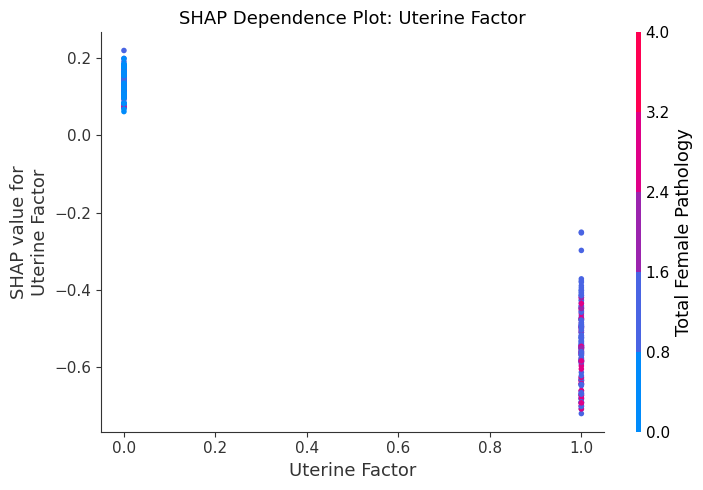

<Figure size 800x600 with 0 Axes>

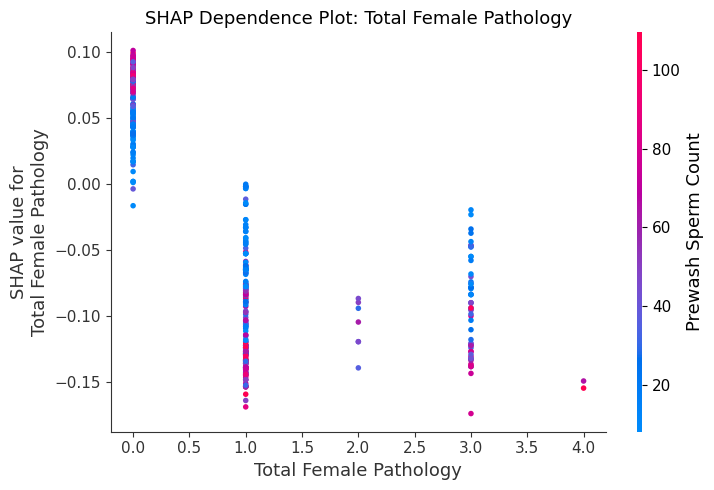

<Figure size 800x600 with 0 Axes>

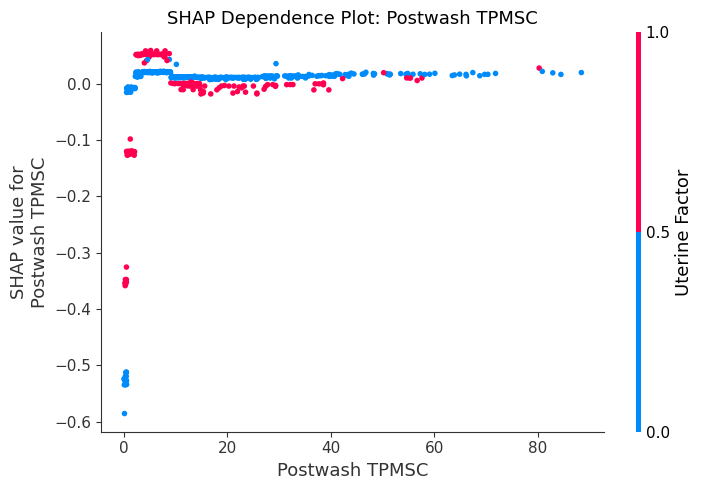

<Figure size 800x600 with 0 Axes>

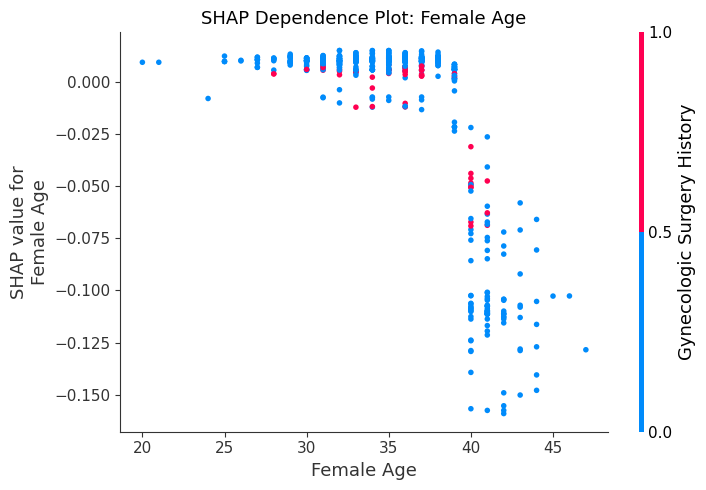

<Figure size 800x600 with 0 Axes>

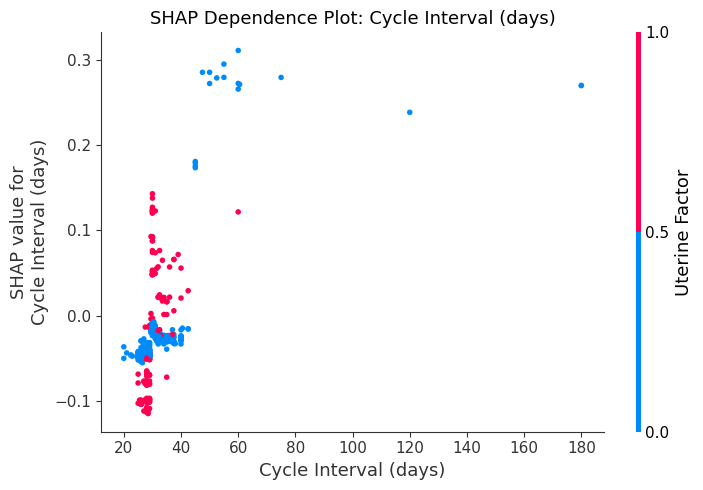

<Figure size 800x600 with 0 Axes>

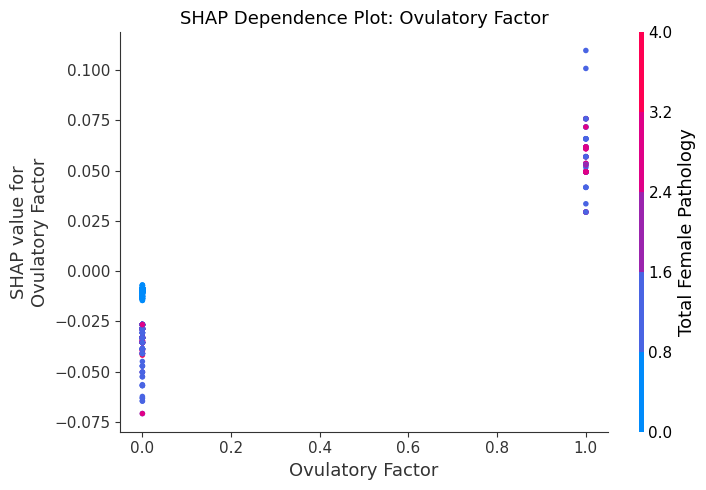

<Figure size 800x600 with 0 Axes>

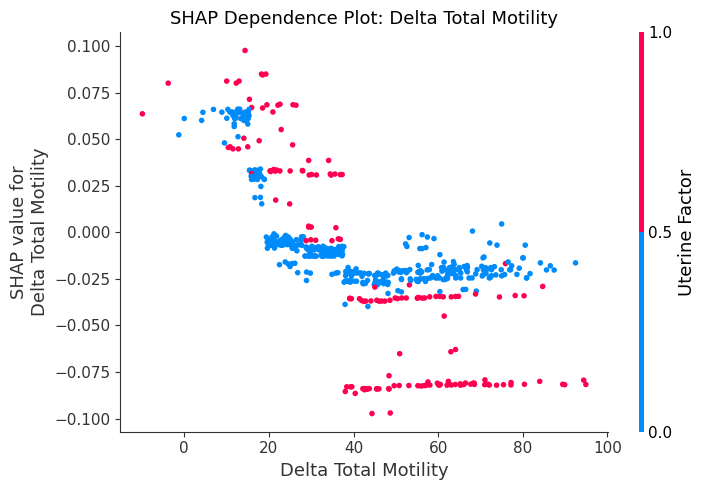

<Figure size 800x600 with 0 Axes>

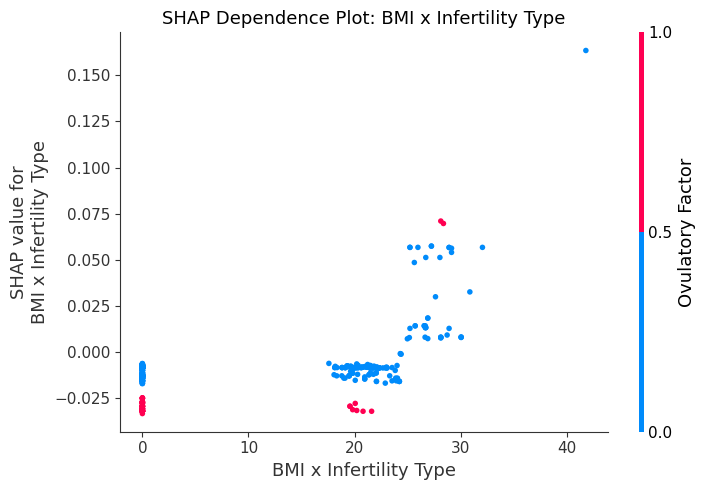

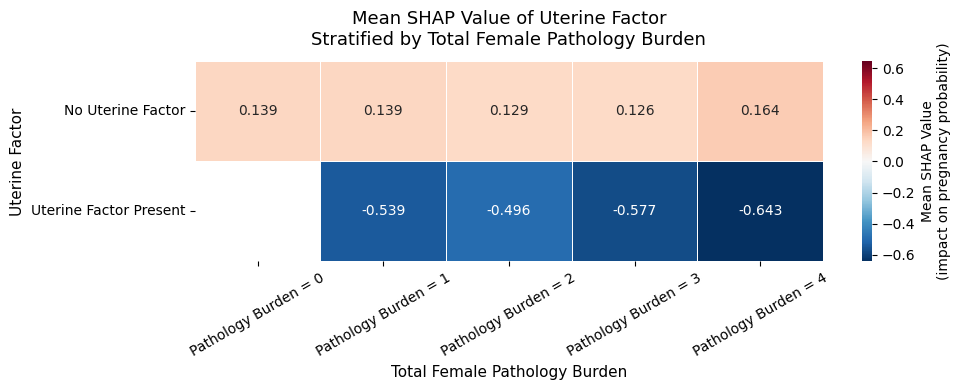

2D SHAP Heatmap: Uterine x Pathology saved


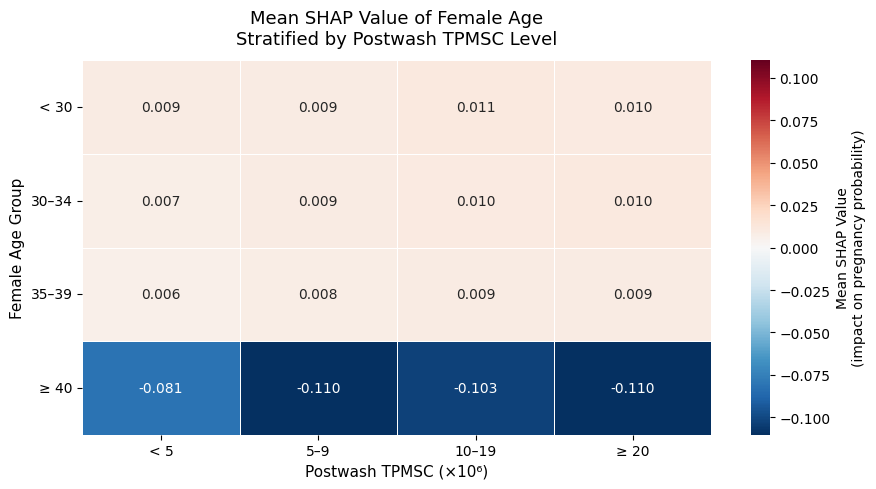

2D SHAP Heatmap: Age x TPMSC saved


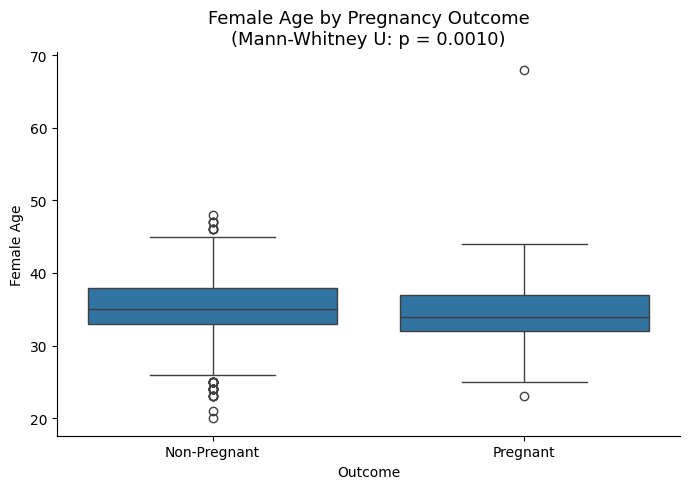

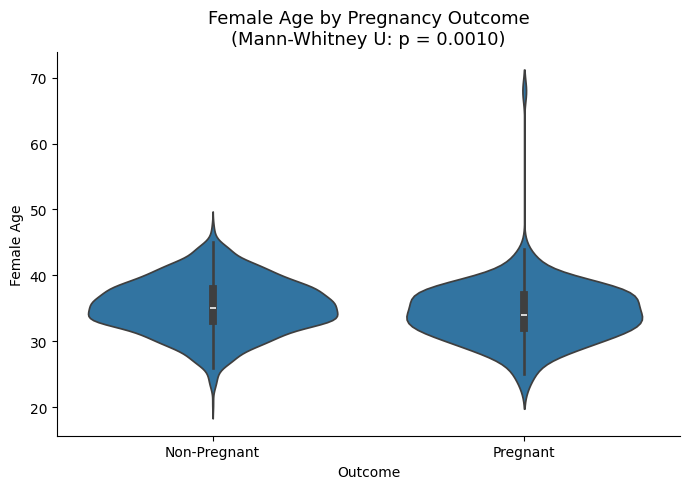

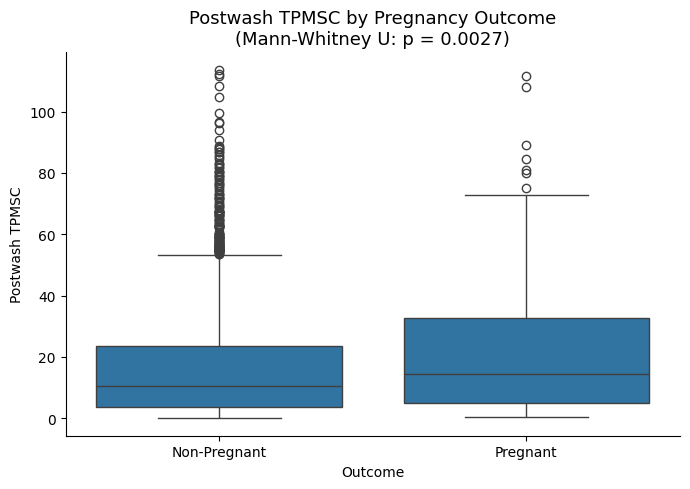

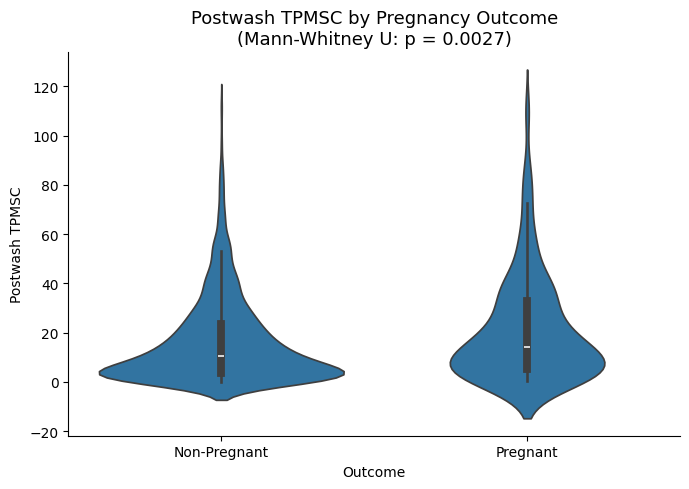

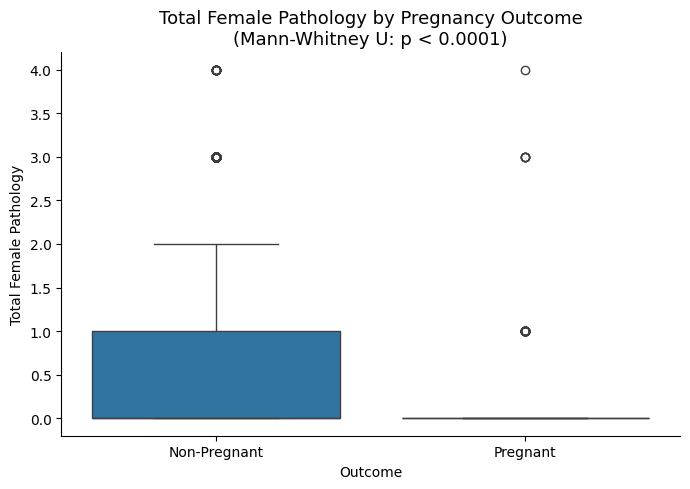

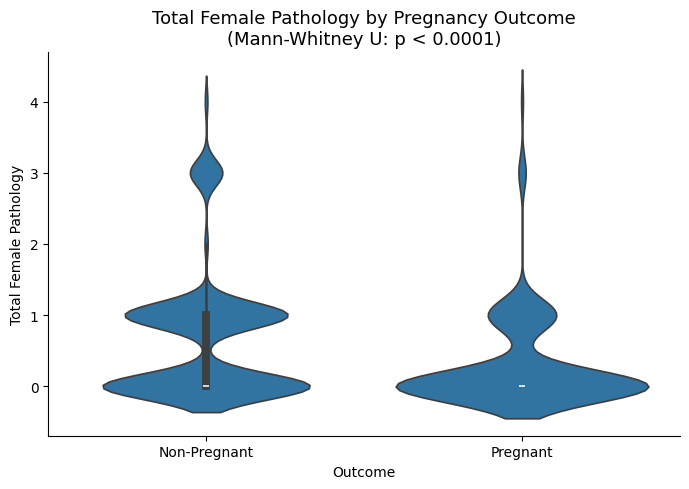

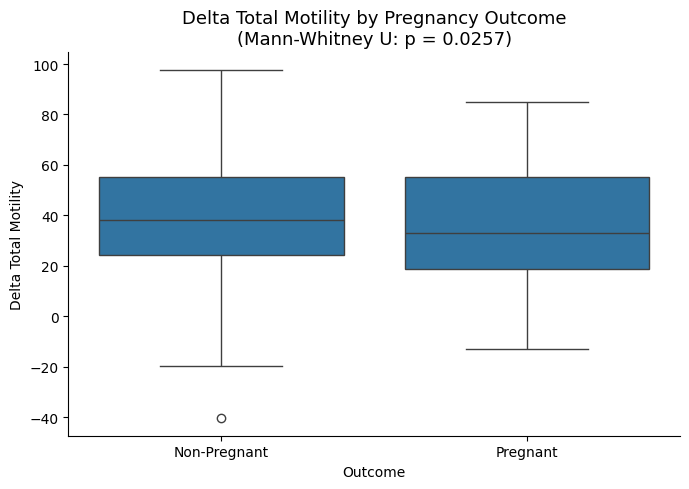

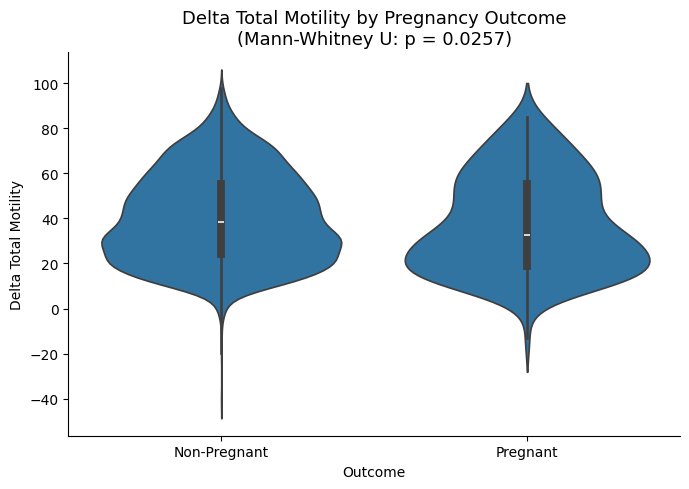


All plots complete.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats

# ==========================================
# Focused SHAP + Clinical Plots
# ==========================================

shap_dependence_dir = FIGURE_DIR / "shap_dependence"
clinical_plots_dir  = FIGURE_DIR / "clinical_plots"
shap_dependence_dir.mkdir(parents=True, exist_ok=True)
clinical_plots_dir.mkdir(parents=True, exist_ok=True)

required_objects = ['feat_imp_final_xgb', 'shap_values', 'X_test_final', 'final_features']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run final SHAP block first.")

# -----------------------------
# Display name setup
# -----------------------------
X_test_final_display = X_test_final.copy()
X_test_final_display.columns = [
    feature_name_map.get(c, c) for c in X_test_final_display.columns
]

raw_to_display = {c: feature_name_map.get(c, c) for c in X_test_final.columns}

def get_display(raw_name):
    return raw_to_display.get(raw_name, raw_name)


# -----------------------------
# 1) SHAP Dependence Plots
# -----------------------------
main_dependence_features = [
    'Uterine_Factors',
    'Total_Female_Pathology',
    'Post_TPMSC',
    'Age_Female',
]

supp_dependence_features = [
    'Menstrual_Interval_Days',
    'Ovulatory_Factors',
]

engineered_dependence_features = [
    'Delta_Motile',
    'BMI_InfertilityType_Interaction',
]

dependence_features = [
    f for f in (
        main_dependence_features +
        supp_dependence_features +
        engineered_dependence_features
    )
    if f in X_test_final.columns
]

print("Dependence features to plot:", dependence_features)

for feat in dependence_features:
    display_name = get_display(feat)

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        display_name,
        shap_values,
        X_test_final_display,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {display_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(
        shap_dependence_dir / f'SHAP_Dependence_{feat}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    plt.close()


# -----------------------------
# 2) 2D SHAP Heatmap: Uterine Factor × Total Female Pathology
# -----------------------------
if {'Uterine_Factors', 'Total_Female_Pathology'}.issubset(X_test_final.columns):

    uterine_idx    = list(X_test_final.columns).index('Uterine_Factors')
    pathology_idx  = list(X_test_final.columns).index('Total_Female_Pathology')

    heatmap_df = pd.DataFrame({
        'Uterine_Factor':         X_test_final['Uterine_Factors'].values.astype(int),
        'Total_Female_Pathology': X_test_final['Total_Female_Pathology'].values.astype(int),
        'SHAP_Uterine':           shap_values[:, uterine_idx]
    })

    heatmap_df = heatmap_df[heatmap_df['Total_Female_Pathology'] <= 4]

    pivot = (
        heatmap_df
        .groupby(['Uterine_Factor', 'Total_Female_Pathology'])['SHAP_Uterine']
        .mean()
        .unstack(fill_value=np.nan)
    )

    pivot = pivot.reindex(sorted(pivot.index))
    pivot.index   = ['No Uterine Factor', 'Uterine Factor Present']
    pivot.columns = [f'Pathology Burden = {c}' for c in pivot.columns]

    vmax = np.nanmax(np.abs(pivot.values))

    fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
    ax.set_facecolor('white')

    sns.heatmap(
        pivot, ax=ax,
        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt='.3f', linewidths=0.5,
        cbar_kws={'label': 'Mean SHAP Value\n(impact on pregnancy probability)'}
    )

    ax.set_title(
        'Mean SHAP Value of Uterine Factor\nStratified by Total Female Pathology Burden',
        fontsize=13, pad=12
    )
    ax.set_xlabel('Total Female Pathology Burden', fontsize=11)
    ax.set_ylabel('Uterine Factor', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(
        shap_dependence_dir / 'SHAP_Heatmap_UterineFactor_x_TotalFemalePathology.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )
    plt.show()
    plt.close()
    print("2D SHAP Heatmap: Uterine x Pathology saved")


# -----------------------------
# 3) 2D SHAP Heatmap: Female Age × Postwash TPMSC
# -----------------------------
if {'Age_Female', 'Post_TPMSC'}.issubset(X_test_final.columns):

    age_idx   = list(X_test_final.columns).index('Age_Female')
    tpmsc_idx = list(X_test_final.columns).index('Post_TPMSC')

    age_bins    = [0, 30, 35, 40, 100]
    age_labels  = ['< 30', '30–34', '35–39', '≥ 40']
    tpmsc_bins  = [0, 5, 10, 20, 1000]
    tpmsc_labels = ['< 5', '5–9', '10–19', '≥ 20']

    heatmap2_df = pd.DataFrame({
        'Age_Group':   pd.cut(X_test_final['Age_Female'].values, bins=age_bins, labels=age_labels, right=False),
        'TPMSC_Group': pd.cut(X_test_final['Post_TPMSC'].values, bins=tpmsc_bins, labels=tpmsc_labels, right=False),
        'SHAP_Age':    shap_values[:, age_idx]
    }).dropna()

    pivot2 = (
        heatmap2_df
        .groupby(['Age_Group', 'TPMSC_Group'], observed=True)['SHAP_Age']
        .mean()
        .unstack(fill_value=np.nan)
    )

    vmax2 = np.nanmax(np.abs(pivot2.values))

    fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
    ax.set_facecolor('white')

    sns.heatmap(
        pivot2, ax=ax,
        cmap='RdBu_r', center=0, vmin=-vmax2, vmax=vmax2,
        annot=True, fmt='.3f', linewidths=0.5,
        cbar_kws={'label': 'Mean SHAP Value\n(impact on pregnancy probability)'}
    )

    ax.set_title(
        'Mean SHAP Value of Female Age\nStratified by Postwash TPMSC Level',
        fontsize=13, pad=12
    )
    ax.set_xlabel('Postwash TPMSC (×10⁶)', fontsize=11)
    ax.set_ylabel('Female Age Group', fontsize=11)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(
        shap_dependence_dir / 'SHAP_Heatmap_FemaleAge_x_PostTPMSC.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )
    plt.show()
    plt.close()
    print("2D SHAP Heatmap: Age x TPMSC saved")


# -----------------------------
# 4) Clinical Descriptive Plots with Statistical Tests
# -----------------------------
plot_df = df.copy()
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]
plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df = plot_df.dropna(subset=['Result'])
plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

clinical_plot_features = [
    'Age_Female',
    'Post_TPMSC',
    'Total_Female_Pathology',
    'Delta_Motile',
]

for feat in clinical_plot_features:
    if feat not in plot_df.columns:
        print(f"Feature not found in plot_df: {feat}")
        continue

    display_name = get_display(feat)

    tmp = plot_df[['Pregnancy_Label', feat]].copy()
    tmp[feat] = pd.to_numeric(tmp[feat], errors='coerce')
    tmp = tmp.dropna(subset=[feat, 'Pregnancy_Label'])

    if tmp.empty:
        print(f"No data for {feat}")
        continue

    # Mann-Whitney U test
    group_0 = tmp.loc[tmp['Pregnancy_Label'] == 'Non-Pregnant', feat]
    group_1 = tmp.loc[tmp['Pregnancy_Label'] == 'Pregnant', feat]
    stat, p_val = stats.mannwhitneyu(group_0, group_1, alternative='two-sided')
    p_label = f"p = {p_val:.4f}" if p_val >= 0.0001 else "p < 0.0001"

    # Boxplot
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    sns.boxplot(data=tmp, x='Pregnancy_Label', y=feat, ax=ax)
    ax.set_title(f'{display_name} by Pregnancy Outcome\n(Mann-Whitney U: {p_label})', fontsize=13)
    ax.set_xlabel('Outcome')
    ax.set_ylabel(display_name)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(
        clinical_plots_dir / f'BoxPlot_{feat}_by_Result.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    plt.close()

    # Violin plot
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    sns.violinplot(data=tmp, x='Pregnancy_Label', y=feat, inner='box', ax=ax)
    ax.set_title(f'{display_name} by Pregnancy Outcome\n(Mann-Whitney U: {p_label})', fontsize=13)
    ax.set_xlabel('Outcome')
    ax.set_ylabel(display_name)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(
        clinical_plots_dir / f'ViolinPlot_{feat}_by_Result.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    plt.close()

print("\nAll plots complete.")

### 5. Clinical Analysis 1: Risk Stratification

Cutoff method: quantiles (0.33, 0.67)
Calibration-derived cutoffs: c1 = 0.038760, c2 = 0.099379


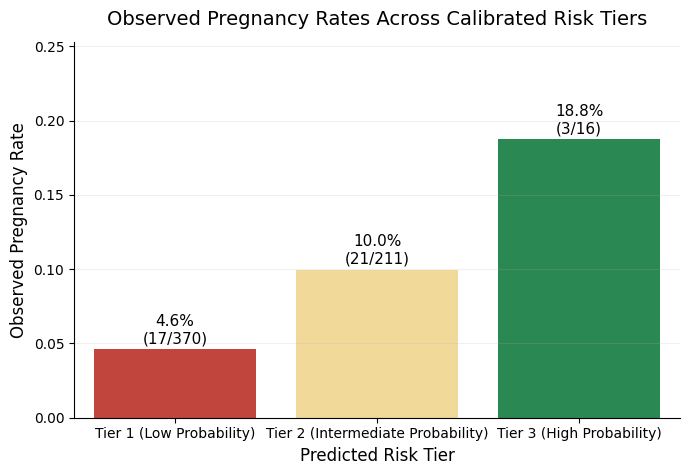


Calibration-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           284                   9   
1  Tier 2 (Intermediate Probability)           187                  18   
2          Tier 3 (High Probability)            10                   3   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.031690            0.000000            0.038760   
1            0.096257            0.076923            0.099379   
2            0.300000            0.222222            1.000000   

   Observed_Pregnancy_Rate  Predicted_minus_Observed      Dataset  
0                 0.031690             -1.521597e-09  Calibration  
1                 0.096257             -3.705369e-09  Calibration  
2                 0.300000              1.192093e-08  Calibration  

Test-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probabi

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Risk Tier Analysis
# Final calibrated model
# Cutoffs derived from calibration set, then applied to test set
# ==========================================

clinical_dir = FIGURE_DIR / "clinical"
clinical_dir.mkdir(parents=True, exist_ok=True)

required_objects = [
    'X_cal', 'y_cal', 'xgb_for_cal', 'iso_reg',
    'X_test_final', 'y_test', 'test_info'
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the calibration block first.")

# --------------------------------
# 1) Calibrated probabilities
# --------------------------------
cal_probs_raw        = xgb_for_cal.predict_proba(X_cal)[:, 1]
cal_probs_calibrated = np.clip(iso_reg.predict(cal_probs_raw), 0, 1)

test_probs_raw        = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = np.clip(iso_reg.predict(test_probs_raw), 0, 1)

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

# --------------------------------
# 2) Robust cutoff selection
# --------------------------------
def get_robust_cutoffs(probs: np.ndarray):
    probs = np.asarray(probs, dtype=float)
    candidate_pairs = [
        (1/3, 2/3), (0.25, 0.75), (0.20, 0.80),
        (0.40, 0.70), (0.30, 0.70),
    ]
    for q1, q2 in candidate_pairs:
        c1 = float(np.quantile(probs, q1))
        c2 = float(np.quantile(probs, q2))
        if np.isfinite(c1) and np.isfinite(c2) and (c1 < c2):
            return c1, c2, f"quantiles ({q1:.2f}, {q2:.2f})"
    return None, None, "rank_fallback"

c1, c2, cutoff_method = get_robust_cutoffs(cal_probs_calibrated)

print("Cutoff method:", cutoff_method)
if c1 is not None and c2 is not None:
    print(f"Calibration-derived cutoffs: c1 = {c1:.6f}, c2 = {c2:.6f}")

# --------------------------------
# 3) Calibration-set tiers
# --------------------------------
risk_cal_df = pd.DataFrame({
    'Predicted_Prob': cal_probs_calibrated,
    'Actual_Result':  y_cal.values
})

if c1 is not None and c2 is not None:
    risk_cal_df['Risk_Tier'] = pd.cut(
        risk_cal_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_labels,
        include_lowest=True
    )
else:
    risk_cal_df = risk_cal_df.sort_values('Predicted_Prob', kind='mergesort').reset_index(drop=True)
    n    = len(risk_cal_df)
    idx1 = int(np.floor(n / 3))
    idx2 = int(np.floor(2 * n / 3))
    risk_cal_df['Risk_Tier'] = tier_labels[0]
    risk_cal_df.loc[idx1:idx2-1, 'Risk_Tier'] = tier_labels[1]
    risk_cal_df.loc[idx2:, 'Risk_Tier']        = tier_labels[2]
    risk_cal_df['Risk_Tier'] = pd.Categorical(
        risk_cal_df['Risk_Tier'], categories=tier_labels, ordered=True
    )

# --------------------------------
# 4) Calibration-set summary
# --------------------------------
cal_tier_summary = (
    risk_cal_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

cal_tier_summary['Observed_Pregnancy_Rate']  = (
    cal_tier_summary['Actual_Pregnancies'] / cal_tier_summary['Total_Cycles']
)
cal_tier_summary['Predicted_minus_Observed'] = (
    cal_tier_summary['Avg_Predicted_Prob'] - cal_tier_summary['Observed_Pregnancy_Rate']
)
cal_tier_summary['Dataset'] = 'Calibration'

# --------------------------------
# 5) Apply tier logic to test set
# --------------------------------
risk_df = test_info.copy()
risk_df['Predicted_Prob'] = test_probs_calibrated
risk_df['Actual_Result']  = y_test.values
risk_df = risk_df.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

if c1 is not None and c2 is not None:
    risk_df['Risk_Tier'] = pd.cut(
        risk_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_labels,
        include_lowest=True
    )
else:
    risk_df = risk_df.sort_values('Predicted_Prob', kind='mergesort').reset_index(drop=True)
    n    = len(risk_df)
    idx1 = int(np.floor(n / 3))
    idx2 = int(np.floor(2 * n / 3))
    risk_df['Risk_Tier'] = tier_labels[0]
    risk_df.loc[idx1:idx2-1, 'Risk_Tier'] = tier_labels[1]
    risk_df.loc[idx2:, 'Risk_Tier']        = tier_labels[2]
    risk_df['Risk_Tier'] = pd.Categorical(
        risk_df['Risk_Tier'], categories=tier_labels, ordered=True
    )

# --------------------------------
# 6) Test-set summary
# --------------------------------
tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:
    patient_counts = (
        risk_df
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate']  = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)
tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)
tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'], categories=tier_labels, ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)
tier_summary['Dataset'] = 'Test'

# --------------------------------
# 7) Save tables
# --------------------------------
cal_tier_summary.to_excel(
    REPORT_DIR / 'Risk_Tier_Summary_CalibrationSet_Calibrated.xlsx', index=False
)
tier_summary.to_excel(
    REPORT_DIR / 'Risk_Tier_Summary_FinalModel_Calibrated.xlsx', index=False
)
risk_df.to_excel(
    REPORT_DIR / 'Risk_Tier_Assignments_TestSet_Calibrated.xlsx', index=False
)

# --------------------------------
# 8) Plot
# --------------------------------
tier_colors = ['#d73027', '#fee08b', '#1a9850']

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier', y='Observed_Pregnancy_Rate',
    data=tier_summary, palette=tier_colors, ax=ax
)

ax.set_title(
    'Observed Pregnancy Rates Across Calibrated Risk Tiers',
    fontsize=14, pad=12
)
ax.set_ylabel('Observed Pregnancy Rate', fontsize=12)
ax.set_xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
ax.set_ylim(0, max(0.05, ymax * 1.35))

for i, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    ax.text(i, row['Observed_Pregnancy_Rate'] + 0.002, label,
            ha='center', va='bottom', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    clinical_dir / 'Risk_Tier_Analysis_FinalModel_Calibrated.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
plt.close()

# --------------------------------
# 9) Print summaries
# --------------------------------
print("\nCalibration-set Risk Tier Summary:")
print(cal_tier_summary)

print("\nTest-set Risk Tier Summary:")
print(tier_summary)

test_rates   = tier_summary['Observed_Pregnancy_Rate'].values
is_monotonic = np.all(np.diff(test_rates) > 0)
print(f"\nMonotonic increase across test tiers: {is_monotonic}")

print("\nRisk tier analysis complete.")

### 6. Clinical Analysis 2: Cumulative Cycle Impact

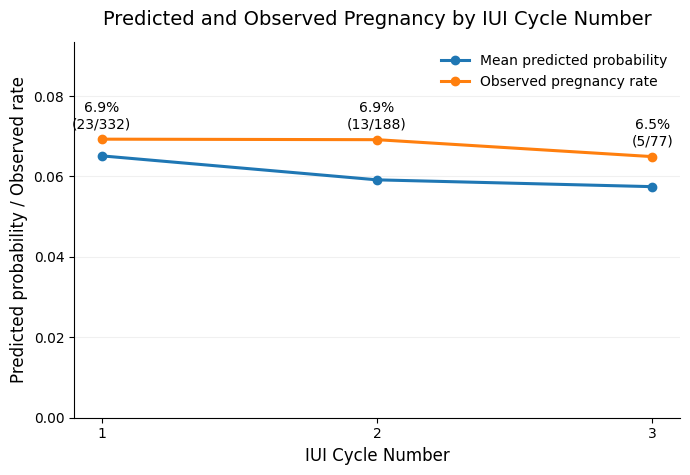


Cycle Summary:
   Cycle_Number  Total_Cycles  Actual_Pregnancies  Avg_Predicted_Prob  \
0             1           332                  23            0.065129   
1             2           188                  13            0.059160   
2             3            77                   5            0.057465   

   Observed_Pregnancy_Rate  
0                 0.069277  
1                 0.069149  
2                 0.064935  


In [44]:
import matplotlib.pyplot as plt

# ==========================================
# Cycle Number Analysis
# Final calibrated model
# ==========================================

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' not in risk_df.columns:
    print("Cycle_Number not found in risk_df.")
else:
    cycle_summary = (
        risk_df
        .groupby('Cycle_Number')
        .agg(
            Total_Cycles=('Actual_Result', 'count'),
            Actual_Pregnancies=('Actual_Result', 'sum'),
            Avg_Predicted_Prob=('Predicted_Prob', 'mean')
        )
        .reset_index()
    )

    cycle_summary['Observed_Pregnancy_Rate'] = (
        cycle_summary['Actual_Pregnancies'] / cycle_summary['Total_Cycles']
    )

    cycle_summary = (
        cycle_summary[cycle_summary['Cycle_Number'].isin([1, 2, 3])]
        .sort_values('Cycle_Number')
        .copy()
    )

    cycle_summary.to_excel(
        REPORT_DIR / 'Cycle_Number_Summary.xlsx',
        index=False
    )

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Avg_Predicted_Prob'],
        marker='o', linewidth=2.2,
        label='Mean predicted probability'
    )

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Observed_Pregnancy_Rate'],
        marker='o', linewidth=2.2,
        label='Observed pregnancy rate'
    )

    for _, row in cycle_summary.iterrows():
        ax.text(
            row['Cycle_Number'],
            row['Observed_Pregnancy_Rate'] + 0.002,
            f"{row['Observed_Pregnancy_Rate']:.1%}\n"
            f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center', va='bottom', fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('IUI Cycle Number', fontsize=12)
    ax.set_ylabel('Predicted probability / Observed rate', fontsize=12)
    ax.set_title(
        'Predicted and Observed Pregnancy by IUI Cycle Number',
        fontsize=14, pad=12
    )

    ymax = max(
        cycle_summary['Avg_Predicted_Prob'].max(),
        cycle_summary['Observed_Pregnancy_Rate'].max()
    )
    ax.set_ylim(0, max(0.05, ymax * 1.35))

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        FIGURE_DIR / "clinical" / 'Cycle_Number_Analysis_Final.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )

    plt.show()
    plt.close()

    print("\nCycle Summary:")
    print(cycle_summary)


Cumulative Pregnancy Summary:
   Patients  Avg_Predicted_Cumulative_Prob  Observed_Pregnancy_Rate
0       353                       0.101544                 0.116147


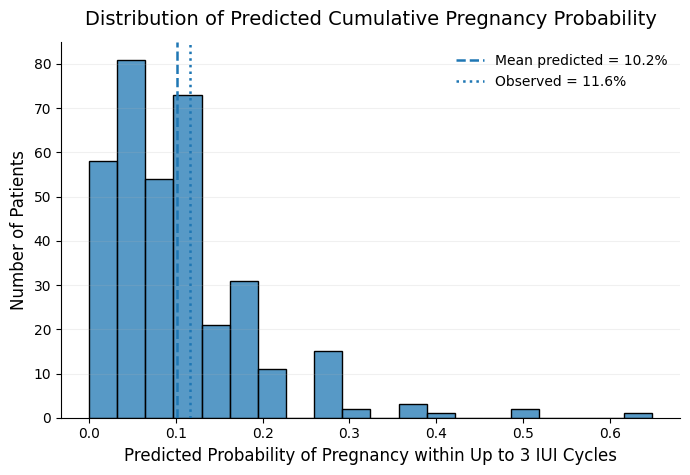

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Cumulative Pregnancy Analysis
# Final calibrated model
# ==========================================

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' not in risk_df.columns or 'HN' not in risk_df.columns:
    print("Cycle_Number or HN not available in risk_df.")
else:
    cum_df = risk_df[risk_df['Cycle_Number'] <= 3].copy()
    cum_df = cum_df.sort_values(['HN', 'Cycle_Number'])

    cumulative_results = []

    for hn, g in cum_df.groupby('HN'):
        g = g.sort_values('Cycle_Number')
        p = g['Predicted_Prob'].values
        cum_prob = 1 - np.prod(1 - p)

        cumulative_results.append({
            'HN':                          hn,
            'Num_Cycles':                  len(g),
            'Cumulative_Predicted_Prob':   cum_prob,
            'Actual_Pregnancy':            g['Actual_Result'].max()
        })

    cumulative_df = pd.DataFrame(cumulative_results)

    cumulative_df.to_excel(
        REPORT_DIR / 'Cumulative_Patient_Level.xlsx', index=False
    )

    cumulative_summary_df = pd.DataFrame([{
        "Patients":                       len(cumulative_df),
        "Avg_Predicted_Cumulative_Prob":  cumulative_df['Cumulative_Predicted_Prob'].mean(),
        "Observed_Pregnancy_Rate":        cumulative_df['Actual_Pregnancy'].mean()
    }])

    cumulative_summary_df.to_excel(
        REPORT_DIR / 'Cumulative_Summary.xlsx', index=False
    )

    print("\nCumulative Pregnancy Summary:")
    print(cumulative_summary_df)

    mean_pred = cumulative_df['Cumulative_Predicted_Prob'].mean()
    obs_rate  = cumulative_df['Actual_Pregnancy'].mean()

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    sns.histplot(
        cumulative_df['Cumulative_Predicted_Prob'],
        bins=20, ax=ax
    )

    ax.axvline(
        mean_pred, linestyle='--', linewidth=1.8,
        label=f'Mean predicted = {mean_pred:.1%}'
    )

    ax.axvline(
        obs_rate, linestyle=':', linewidth=1.8,
        label=f'Observed = {obs_rate:.1%}'
    )

    ax.set_xlabel(
        'Predicted Probability of Pregnancy within Up to 3 IUI Cycles',
        fontsize=12
    )
    ax.set_ylabel('Number of Patients', fontsize=12)
    ax.set_title(
        'Distribution of Predicted Cumulative Pregnancy Probability',
        fontsize=14, pad=12
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        FIGURE_DIR / "clinical" / 'Cumulative_Pregnancy_Distribution.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )

    plt.show()
    plt.close()


Cumulative Success Summary:
   Cycle  Eligible_Patients  Observed_Cumulative_Pregnancy_Rate  \
0      1                353                            0.065156   
1      2                196                            0.102041   
2      3                 77                            0.142857   

   Model_Estimated_Cumulative_Probability  
0                                0.061255  
1                                0.105741  
2                                0.149221  


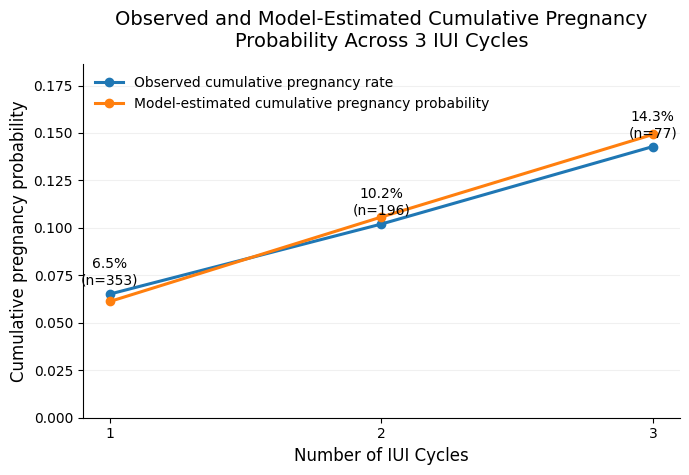

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Cohort-Level Cumulative Success (Cycles 1-3)
# Final calibrated model
# ==========================================

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Please run the calibrated risk-tier block first.")

if 'Cycle_Number' not in risk_df.columns or 'HN' not in risk_df.columns:
    print("HN and Cycle_Number are both required for cumulative success analysis.")
else:
    cum_plot_df = (
        risk_df[risk_df['Cycle_Number'] <= 3]
        .copy()
        .sort_values(['HN', 'Cycle_Number'])
    )

    summary_rows = []

    for k in [1, 2, 3]:
        eligible_hn = (
            cum_plot_df.groupby('HN')['Cycle_Number']
            .max()
        )
        eligible_hn = eligible_hn[eligible_hn >= k].index

        sub = cum_plot_df[
            (cum_plot_df['HN'].isin(eligible_hn)) &
            (cum_plot_df['Cycle_Number'] <= k)
        ].copy()

        observed_by_patient = (
            sub.groupby('HN')['Actual_Result']
            .max()
            .reindex(eligible_hn, fill_value=0)
        )

        pred_by_patient = []
        for hn in eligible_hn:
            g = sub[sub['HN'] == hn].sort_values('Cycle_Number')
            p = g['Predicted_Prob'].values
            cum_prob = 1 - np.prod(1 - p)
            pred_by_patient.append(cum_prob)

        summary_rows.append({
            'Cycle':                                 k,
            'Eligible_Patients':                     len(eligible_hn),
            'Observed_Cumulative_Pregnancy_Rate':    observed_by_patient.mean(),
            'Model_Estimated_Cumulative_Probability': float(np.mean(pred_by_patient))
        })

    cumulative_summary_df = pd.DataFrame(summary_rows)

    cumulative_summary_df.to_excel(
        REPORT_DIR / 'Cumulative_Success_By_Cycle.xlsx', index=False
    )

    print("\nCumulative Success Summary:")
    print(cumulative_summary_df)

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'],
        marker='o', linewidth=2.2,
        label='Observed cumulative pregnancy rate'
    )

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'],
        marker='o', linewidth=2.2,
        label='Model-estimated cumulative pregnancy probability'
    )

    for _, row in cumulative_summary_df.iterrows():
        ax.text(
            row['Cycle'],
            row['Observed_Cumulative_Pregnancy_Rate'] + 0.005,
            f"{row['Observed_Cumulative_Pregnancy_Rate']:.1%}\n"
            f"(n={int(row['Eligible_Patients'])})",
            ha='center', fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Cumulative pregnancy probability', fontsize=12)
    ax.set_title(
        'Observed and Model-Estimated Cumulative Pregnancy\nProbability Across 3 IUI Cycles',
        fontsize=14, pad=12
    )

    ymax = max(
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'].max(),
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'].max()
    )
    ax.set_ylim(0, max(0.05, ymax * 1.25))

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        FIGURE_DIR / "clinical" / 'Cumulative_Success_By_Cycle.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )

    plt.show()
    plt.close()


Cumulative by Baseline Risk Tier (Fixed Cohort):
                  Baseline_Risk_Tier  Cycle  Patients_in_Tier  \
0           Tier 1 (Low Probability)      1               198   
1           Tier 1 (Low Probability)      2               198   
2           Tier 1 (Low Probability)      3               198   
3  Tier 2 (Intermediate Probability)      1               123   
4  Tier 2 (Intermediate Probability)      2               123   
5  Tier 2 (Intermediate Probability)      3               123   
6          Tier 3 (High Probability)      1                11   
7          Tier 3 (High Probability)      2                11   
8          Tier 3 (High Probability)      3                11   

   Observed_Cumulative_Pregnancy_Rate  Pregnancies_by_Cycle_k  
0                            0.040404                       8  
1                            0.085859                      17  
2                            0.101010                      20  
3                            0.105691      

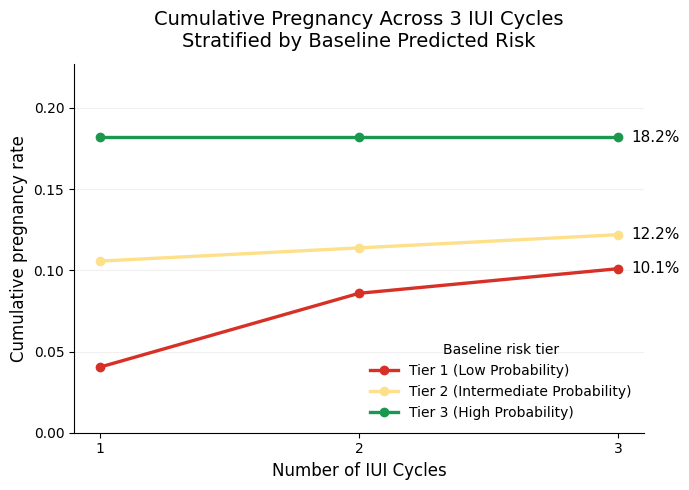

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Cumulative Pregnancy by Baseline Risk Tier (Fixed Cohort)
# Final calibrated model
# ==========================================

if 'risk_df' not in globals():
    raise ValueError("risk_df not found. Run calibrated model block first.")

if 'c1' not in globals() or 'c2' not in globals():
    raise ValueError("c1/c2 not found. Run risk-tier block first.")

if 'HN' not in risk_df.columns or 'Cycle_Number' not in risk_df.columns:
    print("HN and Cycle_Number are both required.")
else:
    tier_order = [
        'Tier 1 (Low Probability)',
        'Tier 2 (Intermediate Probability)',
        'Tier 3 (High Probability)'
    ]

    df = (
        risk_df[risk_df['Cycle_Number'] <= 3]
        .copy()
        .sort_values(['HN', 'Cycle_Number'])
    )

    # --------------------------------
    # 1) Define baseline tier (cycle 1)
    # --------------------------------
    baseline = df[df['Cycle_Number'] == 1].copy()

    baseline['Baseline_Risk_Tier'] = pd.cut(
        baseline['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_order,
        include_lowest=True
    )

    baseline_map = baseline[['HN', 'Baseline_Risk_Tier']].drop_duplicates()
    df = df.merge(baseline_map, on='HN', how='inner')

    # --------------------------------
    # 2) Cumulative fixed cohort
    # --------------------------------
    rows = []

    for tier in tier_order:
        sub = df[df['Baseline_Risk_Tier'] == tier].copy()

        if sub.empty:
            continue

        patient_ids = sub['HN'].unique()

        for k in [1, 2, 3]:
            sub_k = sub[sub['Cycle_Number'] <= k].copy()

            preg_by_patient = (
                sub_k.groupby('HN')['Actual_Result']
                .max()
                .reindex(patient_ids, fill_value=0)
            )

            rows.append({
                'Baseline_Risk_Tier':                  tier,
                'Cycle':                               k,
                'Patients_in_Tier':                    len(patient_ids),
                'Observed_Cumulative_Pregnancy_Rate':  preg_by_patient.mean(),
                'Pregnancies_by_Cycle_k':              int(preg_by_patient.sum())
            })

    result_df = pd.DataFrame(rows)

    result_df.to_excel(
        REPORT_DIR / 'Cumulative_Pregnancy_By_Baseline_Risk_Tier_FIXED.xlsx',
        index=False
    )

    print("\nCumulative by Baseline Risk Tier (Fixed Cohort):")
    print(result_df)

    # --------------------------------
    # 3) Plot
    # --------------------------------
    tier_color_map = {
        'Tier 1 (Low Probability)':           '#d73027',
        'Tier 2 (Intermediate Probability)':  '#fee08b',
        'Tier 3 (High Probability)':          '#1a9850'
    }

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    for tier in tier_order:
        sub = result_df[result_df['Baseline_Risk_Tier'] == tier]

        if sub.empty:
            continue

        ax.plot(
            sub['Cycle'],
            sub['Observed_Cumulative_Pregnancy_Rate'],
            marker='o', linewidth=2.4,
            label=tier,
            color=tier_color_map[tier]
        )

        last = sub.sort_values('Cycle').iloc[-1]
        ax.text(
            last['Cycle'] + 0.05,
            last['Observed_Cumulative_Pregnancy_Rate'],
            f"{last['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            fontsize=11, va='center'
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Cumulative pregnancy rate', fontsize=12)
    ax.set_title(
        'Cumulative Pregnancy Across 3 IUI Cycles\nStratified by Baseline Predicted Risk',
        fontsize=14, pad=12
    )

    ymax = result_df['Observed_Cumulative_Pregnancy_Rate'].max()
    ax.set_ylim(0, ymax * 1.25)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(title='Baseline risk tier', frameon=False)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "clinical" / 'Cumulative_Pregnancy_By_Baseline_Risk_Tier_FIXED.png',
        dpi=300, bbox_inches='tight', facecolor='white'
    )

    plt.show()
    plt.close()

### 7. Decision Curve Analysis (DCA)

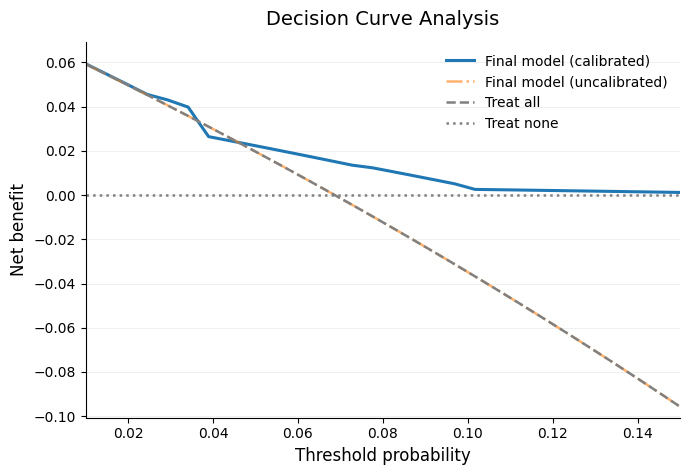


DCA complete.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Decision Curve Analysis
# Final calibrated model
# ==========================================

dca_dir = FIGURE_DIR / "dca"
dca_dir.mkdir(parents=True, exist_ok=True)

thresholds = np.linspace(0.01, 0.15, 30)

required_objects = ['y_test', 'test_probs_raw', 'test_probs_calibrated']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Run the calibration block first.")

# -----------------------------
# Net benefit calculations
# -----------------------------
nb_model_raw = [calculate_net_benefit(y_test, test_probs_raw, t) for t in thresholds]
nb_model_cal = [calculate_net_benefit(y_test, test_probs_calibrated, t) for t in thresholds]
nb_all       = [calculate_net_benefit(y_test, np.ones(len(y_test)), t) for t in thresholds]
nb_none      = [0.0] * len(thresholds)

# -----------------------------
# Save table
# -----------------------------
dca_df = pd.DataFrame({
    'Threshold':              thresholds,
    'Net_Benefit_Raw':        nb_model_raw,
    'Net_Benefit_Calibrated': nb_model_cal,
    'Treat_All':              nb_all,
    'Treat_None':             nb_none
})

dca_df.to_excel(REPORT_DIR / 'DCA_Analysis_Final_Model.xlsx', index=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

ax.plot(
    thresholds, nb_model_cal,
    linewidth=2.2,
    label='Final model (calibrated)'
)

ax.plot(
    thresholds, nb_model_raw,
    linewidth=1.8, linestyle='-.', alpha=0.6,
    label='Final model (uncalibrated)'
)

ax.plot(
    thresholds, nb_all,
    color='gray', linestyle='--', linewidth=1.8,
    label='Treat all'
)

ax.plot(
    thresholds, nb_none,
    color='gray', linestyle=':', linewidth=1.8,
    label='Treat none'
)

ax.set_xlabel('Threshold probability', fontsize=12)
ax.set_ylabel('Net benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, pad=12)

ax.set_xlim(0.01, 0.15)

ymin = min(np.nanmin(nb_model_raw), np.nanmin(nb_model_cal), np.nanmin(nb_all), 0)
ymax = max(np.nanmax(nb_model_raw), np.nanmax(nb_model_cal), np.nanmax(nb_all), 0)
ax.set_ylim(ymin - 0.005, ymax + 0.01)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    dca_dir / 'DCA_Final_Model.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)

plt.show()
plt.close()

print("\nDCA complete.")

In [49]:
import pandas as pd

# ==========================================
# Default Values for Web App
# Binary: mode, Continuous: median
# ==========================================

df_clean = pd.read_csv(
    DATA_PATH.parent / "cycle_level_ready_for_ml.csv"
)

binary_cols = [
    "Uterine_Factors", "Tubal_Factors", "Ovarian_Factors",
    "Ovulatory_Factors", "Cervical_Factors", "Endometriosis_Factors",
    "Multisystem_Factors", "Gynecological_Surgical_History",
    "Infertility_Type"
]

continuous_cols = [
    "Cycle_Day", "Post_TPMSC", "First_Count", "Pre_Count",
    "Post_Count", "Post_Motile", "Pre_Motile", "Age_Female",
    "First_Progressive_Motile", "First_Volume",
    "Menstrual_Interval_Days", "First_Motile", "Body_Mass_Index"
]

print("=== Binary (Mode) ===")
for c in binary_cols:
    if c in df_clean.columns:
        mode_val = float(df_clean[c].mode()[0])
        print(f'    "{c}": {mode_val},')

print("\n=== Continuous (Median) ===")
for c in continuous_cols:
    if c in df_clean.columns:
        median_val = float(df_clean[c].median())
        print(f'    "{c}": {median_val},')

=== Binary (Mode) ===
    "Uterine_Factors": 0.0,
    "Tubal_Factors": 0.0,
    "Ovarian_Factors": 0.0,
    "Ovulatory_Factors": 0.0,
    "Cervical_Factors": 0.0,
    "Endometriosis_Factors": 0.0,
    "Multisystem_Factors": 0.0,
    "Gynecological_Surgical_History": 0.0,
    "Infertility_Type": 0.0,

=== Continuous (Median) ===
    "Cycle_Day": 14.0,
    "Post_TPMSC": 10.641124,
    "First_Count": 41.31,
    "Pre_Count": 42.6,
    "Post_Count": 22.2,
    "Post_Motile": 96.93,
    "Pre_Motile": 57.6,
    "Age_Female": 35.0,
    "First_Progressive_Motile": 52.56,
    "First_Volume": 3.0,
    "Menstrual_Interval_Days": 29.0,
    "First_Motile": 54.7,
    "Body_Mass_Index": 21.71806608974573,
